# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

# План работы

## Этап 1. Подготовка среды и библиотек
1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируйте `random_state`.

3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.

In [1]:
#!pip install phik
!pip install --upgrade phik

In [2]:
!pip install --upgrade scikit-learn 
#!pip uninstall feature-engine
##!pip install --upgrade category_encoders 
#!pip uninstall scikit-learn установлена 1.8.0

In [3]:
!pip install --upgrade category_encoders
#!pip install --upgrade --force-reinstall category_encoders

In [4]:
!pip install joblib

import pkg_resources  # Эта библиотека уже есть в Python

try:
    # Используем pkg_resources, чтобы получить версию
    version = pkg_resources.get_distribution("category_encoders").version
    print("Category encoders version:", version)
except pkg_resources.DistributionNotFound:
    print("Package 'category_encoders' is not installed.")

try:
    # Получаем версию через стандартную библиотеку importlib
    import importlib.metadata as metadata
    version = metadata.version("category_encoders")
    print("Category encoders version:", version)
except metadata.PackageNotFoundError:
    print("Package 'category_encoders' is не найдено. Пожалуйста, убедитесь, что он установлен для текущего ядра Python.")

In [5]:
#!pip show scikit-learn
#!pip show category_encoders


In [6]:
#!pip install --upgrade pandas scikit-learn

In [7]:
# Библиотеки для работы с данными и визуализации
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import category_encoders
from phik import phik_matrix
import joblib

# Основная библиотека машинного обучения
import sklearn

# Классы из sklearn для разбиения данных и кросс-валидации
from sklearn.model_selection import train_test_split, KFold, cross_validate, StratifiedKFold

# Классы для построения пайплайнов
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Трансформеры для предобработки данных
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Энкодеры категориальных признаков
from category_encoders import TargetEncoder

# Базовые классы для создания собственных трансформеров
from sklearn.base import BaseEstimator, TransformerMixin

# Модель для классификации
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, average_precision_score
from sklearn.dummy import DummyClassifier

In [8]:
print("Scikit-learn version:", sklearn.__version__)
print("Category encoders version:", category_encoders.__version__)

Scikit-learn version: 1.9.0
Category encoders version: 2.8.1


In [9]:
RANDOM_STATE=42 

In [10]:
df=pd.read_csv('coffee_churn_dataset.csv', decimal=".") 

Создала копию датафрейма: **df_pipe**, по которому будет проводиться предобработка данных на **этапе3** и все остальные этапы

In [11]:
df_pipe=df.copy()

## Этап 2. Первичный анализ данных

1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.

2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

4. Обработайте пропущенные значения.
   
   - Объясните, как они влияют на данные.

   - Выберите стратегию заполнения пропусков.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.

   - Определите, есть ли в данных признаки, которые можно удалить.

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.

   - Выберите способ, которым их можно обработать.

7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

8. Напишите выводы по результатам исследовательского анализа данных.

2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

**Целевая переменная** для оценки оттока клиентов - `churn`, которая характеризует, перестал ли пользователь пользоваться сервисом.

Остальные **25** столбцов  характеризуют пользователей их решено оставить в модели. Кроме столбца `user_id` - идентификатор пользователя, поскольку не является характеристикой. **Исключим `user_id` из датафрейма**.


### 1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.

In [12]:
BOLD = '\033[1m'
RESET = '\033[0m'
def show_df(tmp0):
    # Создаем словарь для переименования столбцов
    rename_dict = {}
    for col in tmp0.columns:
        str_bad = col
        if str_bad[0].isupper():
            str_bad = str_bad[0].lower() + str_bad[1:]
        for index_s, item_s in enumerate(str_bad):
            if item_s.isupper():
                str_bad = str_bad[:index_s] + '_' + str_bad[index_s].lower() + str_bad[index_s + 1:]
        rename_dict[col] = str_bad
    
    # Переименовываем все столбцы сразу
    tmp0 = tmp0.rename(columns=rename_dict)
    
    # Вывод информации о датафрейме
    display(tmp0.head())
    print('\n' + '='*50 + '\nИнформация о DataFrame:\n' + '='*50)
    tmp0.info()
    
     # Вывод названий полей и подсчёт их типов с описанием
    count_float = 0
    count_object=0
    count_int=0
    count_datetime=0
    list_fl=[]
    list_obj=[]
    list_int=[]
    list_dt=[]
    for col in tmp0.columns:
        if tmp0[col].dtype in ['float16', 'float32', 'float64']:
            list_fl.append(col)
            count_float += 1
        if tmp0[col].dtype in ['object']:
            list_obj.append(col)
            count_object += 1
        if tmp0[col].dtype in ['int16', 'int32', 'int64']:
            list_int.append(col)
            count_int += 1
        if tmp0[col].dtype in ['datetime64[ns]']:
            list_dt.append(col)
            count_datetime += 1
        
    return print(f'\n Датафрейм содержит: строк - {BOLD}{tmp0.shape[0]}{RESET}, столбцов - {BOLD}{tmp0.shape[1]}{RESET} \n'
                 f'\n Названия столбцов датафрейма приведены к стилю {BOLD}snake case{RESET} \n'
                 f'\n Столбцов типа {BOLD}float{RESET}: {count_float} : {list_fl}\n' 
                 f'\n Столбцов типа {BOLD}object: {count_object}{RESET}\n : {list_obj}'
                 f'\n Столбцов типа {BOLD}int: {count_int}{RESET}\n : {list_int}'
                 f'\n Столбцов типа {BOLD}datetime: {count_datetime}{RESET} :{list_dt}'
                 )

show_df(df)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1



Информация о DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  object 
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  object 
 10  preferred_roast           10334 non-null  object 
 11  milk_preference           9782 non-null   object 
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-n

Типы полей представлены верно. Можно уменьшить разрядность полей для 

In [13]:
# Преобразовывает список полей в заданный тип поля с понижением разрядности,
# считает количество преобразований, пишет вывод
BOLD = '\033[1m'
RESET = '\033[0m'

def type_to_type(tmp0, value, to_type):
    '''
    Преобразовывает список полей в заданный тип поля с понижением разрядности,
    считает количество преобразований, пишет вывод

    tmp0 - имя датафрейма
    value - список полей, которые надо преобразовать/понизить разрядность
    to_type - тип, в который надо преобразовать поле (строка, например 'float32')
    '''
    results = []  # Для хранения сообщений о преобразованиях
    count_col = 0

    # Проверка существования колонок
    missing_cols = [col for col in value if col not in tmp0.columns]
    if missing_cols:
        print(f"Предупреждение: колонки {missing_cols} не найдены в DataFrame.")
        value = [col for col in value if col in tmp0.columns]  # Фильтруем список

    if to_type in ['float16', 'float32', 'float64', 'float']:
        for col in value:
            tmp0[col] = pd.to_numeric(tmp0[col], downcast='float')
            count_col += 1
            results.append(f'{col}')
    elif to_type in ['int16', 'int32', 'int64', 'int']:
        for col in value:
            tmp0[col] = pd.to_numeric(tmp0[col], downcast='integer')
            count_col += 1
            results.append(f'{col}')
    elif to_type in ['datetime64','datetime64[ns]', 'datetime']:
        for col in value:
            try:
                tmp0[col] = pd.to_datetime(tmp0[col])
                count_col+=1
                results.append(f'{col}')
            except ValueError as e:
                print(f'Ошибка при преобразовании {col}: {e}')

    return print('\n'.join(results), f"\n\nВсего преобразовано в {BOLD} {to_type} {RESET} с понижением разрядности {BOLD} {count_col} {RESET} полей\n")  # Возвращаем отчёт для дальнейшего использования

type_to_type(df, ['churn'], 'int')
type_to_type(df, ['days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 
                  'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 
                  'seasonal_menu_tried', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 
                  'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'coffee_preference_change'], 'float')


churn 

Всего преобразовано в  int  с понижением разрядности  1  полей

days_since_last_order
order_frequency_month
order_frequency_week
avg_order_value
median_order_value
total_spent_last_month
total_spent_last_week
discount_usage_rate
seasonal_menu_tried
app_opens_per_week
notifications_enabled
review_rating_last_10
review_rating_last_1
app_crashes_last_month
days_since_last_promo
coffee_preference_change 

Всего преобразовано в  float  с понижением разрядности  16  полей



Разрядности понижены до:
- **float32** для полей: `'days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value',  'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'seasonal_menu_tried', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'coffee_preference_change'`
- **int8** для поля `churn`                   
                  

### Нормализуем категориальные столбцы

In [14]:
# Нормализация и анализ категориальных данных
def analiz_category (value):
    '''
    Нормализация и анализ категориальных данных
    value - список полей/поле
    '''
    # нормализация
    rez=[]
    for col in value:
        df[col]=df[col].str.lower()
        df[col]=df[col].str.strip()
        rez.append(col)
    # анализ категориальных значений
    print(f'Проведена нормализация и анализ данных в {rez}: преобразованы данные к нижнему регистру, убраны лишние пробелы в начале строки и в конце строки. ')
    for column in value:
        print(f"\nColumn: {column}")
        print("\nUnique values:", df[column].unique())
        print("\nUnique values count:", df[column].nunique())
        print("\nMissing values count:", df[column].isna().sum())
        if df[column].isna().any()==True:  # есть ли хоть один пропуск
            proportion_of=df[column].isna().sum()/df.shape[0]
            print("\nProportion of missing values:", proportion_of)
        print("\nValue counts:\n")
        print(df[column].value_counts(dropna=False), "\n")

analiz_category (['user_id', 'last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 
                  'last_drink_size', 'subscription_status', 'seasons', 'phone_type', 'geo_location'])  #  поле
# analiz_category(['columnname', 'columnname', 'columnname', 'columnname'])

Проведена нормализация и анализ данных в ['user_id', 'last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'seasons', 'phone_type', 'geo_location']: преобразованы данные к нижнему регистру, убраны лишние пробелы в начале строки и в конце строки. 

Column: user_id

Unique values: ['user_00318' 'user_07234' 'user_04816' ... 'user_05390' 'user_00860'
 'user_07270']

Unique values count: 10450

Missing values count: 0

Value counts:

user_id
user_07270    1
user_00318    1
user_06420    1
user_01184    1
user_04555    1
             ..
user_08887    1
user_01247    1
user_09698    1
user_04419    1
user_04816    1
Name: count, Length: 10450, dtype: int64 


Column: last_coffee_type

Unique values: ['blend' 'arabica' 'robusta' nan]

Unique values count: 3

Missing values count: 258

Proportion of missing values: 0.024688995215311003

Value counts:

last_coffee_type
arabica    6134
robusta    2524
blend      1534
NaN        

- Проведена нормализация и анализ данных в `['user_id', 'last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'seasons', 'phone_type', 'geo_location']`: преобразованы данные к нижнему регистру, убраны лишние пробелы в начале строки и в конце строки. 

- `user_id`: 10450 значений, прорусков нет
- `last_coffee_type`: ['blend' 'arabica' 'robusta' nan], пропусков 258 (0,024)). Больше всего arabica    6134, robusta    2524 и blend      1534.
- `preferred_roast`: ['light' 'medium' 'dark' nan], пропусков 116 (0,011). medium    3458, light     3453, dark      3423
- `milk_preference` 6 кат: ['almond' 'whole' 'oat' 'skim' 'soy' nan 'none'] пропусков 668 (0,064). Больше всего whole     2876.
- `coffee_bean_origin` 6 кат: ['vietnam' 'guatemala' 'brazil' 'colombia' 'kenya' nan 'ethiopia'] пропусков 682 (0,065). Количество распределено равномерно по категориам от 1690 (ethiopia) до 1580 (colombia)
- `last_drink_size` 3 кат: ['large' 'medium' 'small' nan], пропусков 504 (0,048). Больше всего medium    4925, large     2997, small     2024
- `subscription_statu`s кат 4: ['pro' 'none' 'premium' 'basic' nan] пропусков 938 (0,0898). Лидер: none       3803, basic      2862, premium    1923, pro         924
- `seasons` 4 кат: ['summer' 'autumn' 'spring' 'winter' nan] пропусков 679 (0,064). Распределение равномерное по категориям от 2507 весной до 2408 летом
- `phone_type` 3 кат: ['android' 'ios' 'web' nan] пропуски 336 (0,032). Больше всего android    4611  и ios        4502
- `geo_location` 100 категорий, пропусков 110 (0,01). Лидеры geo_2     1629, geo_3     1573 и geo_1     1532.

Определим пропуски в категориях и посчитаем их долю. 

Пропуски можно: либо оставить как есть, можно ещё заменить на каккой-либо индикатор, "-1", например

In [15]:
# Сколько  пропусков в категориальных столбцах всего
df_drop=df.dropna(subset=['last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 
                  'last_drink_size', 'subscription_status', 'seasons', 'phone_type', 'geo_location'])
proportion=(len(df)-len(df_drop))/len(df)
display(f'Доля пропусков во всех категориальных столбцах: {proportion}')
        

'Доля пропусков во всех категориальных столбцах: 0.34688995215311'

**Мы не можем удалить 35% записей из датафрейма, поэтому пока оставим как есть, без изменений**

### Удалим явные дубликаты

In [16]:
def obvious_duplicates(tmp0):
    """
    Функция для удаления явных дубликатов.
    """
    # Отсортируем датафрейм по всем столбцам
    df_sorted = tmp0.sort_values(by=tmp0.columns.tolist())
    # Находим дубликаты
    duplicates = df_sorted[df_sorted.duplicated(keep=False)]

    df_no_duplicated = df_sorted.drop_duplicates()
    display(f'Удалено явных дубликатов: {duplicates.shape[0]}, Число строк в датафрейме: {df_no_duplicated.shape[0]}')
    return df_no_duplicated

df=obvious_duplicates(df)

df.shape

'Удалено явных дубликатов: 0, Число строк в датафрейме: 10450'

(10450, 27)

**Явных дубликатов нет**. Поищем неявные по всем 25 полям-признакам: 0 записей

Поищем неявные по 7 полям-признакам: ['churn', 'subscription_status', 'phone_type', 'geo_location', 'notifications_enabled',
'review_rating_last_10', 'review_rating_last_1'] **455** записей

**Удалим из датафрейма df неявные дубликаты!!!**


In [17]:
def implicit_duplicates(values):
    # Отсортируем датафрейм по свем столбцам
    df_sorted3=df.sort_values(by=df.columns.tolist())
     # Удаляем дубликаты (1 запись удалим)
    df_no_duplicated3=df_sorted3.drop_duplicates(subset=values)
    count_df_no_duplicated3=df.shape[0]-df_no_duplicated3.shape[0]
    display(f'Удалено неявных дубликатов по столбцам {values}: {count_df_no_duplicated3}')
    procent=round(1-df_no_duplicated3.shape[0]/len(df_sorted3), 3)
    print(f'доля неявных дубликатов в датафрейме {procent} ')
    return df_no_duplicated3
    
df=implicit_duplicates(['churn', 'subscription_status', 'phone_type', 'geo_location', 'notifications_enabled',
'review_rating_last_10', 'review_rating_last_1']).copy()

"Удалено неявных дубликатов по столбцам ['churn', 'subscription_status', 'phone_type', 'geo_location', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1']: 455"

доля неявных дубликатов в датафрейме 0.044 


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9995 entries, 1128 to 7457
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   9995 non-null   object 
 1   days_since_last_order     9095 non-null   float32
 2   order_frequency_month     9414 non-null   float32
 3   order_frequency_week      9621 non-null   float32
 4   avg_order_value           9437 non-null   float32
 5   median_order_value        9197 non-null   float32
 6   total_spent_last_month    9708 non-null   float64
 7   total_spent_last_week     9086 non-null   float32
 8   discount_usage_rate       9613 non-null   float32
 9   last_coffee_type          9745 non-null   object 
 10  preferred_roast           9884 non-null   object 
 11  milk_preference           9356 non-null   object 
 12  seasonal_menu_tried       9048 non-null   float32
 13  coffee_bean_origin        9354 non-null   object 
 14  last_drink

### Исследуем числовые признаки

Описательные статистики для столбца  days_since_last_order :
count    9095.000000
mean        4.391754
std         4.851436
min         0.000000
25%         1.000000
50%         3.000000
75%         6.000000
max        40.000000
Name: days_since_last_order, dtype: float64


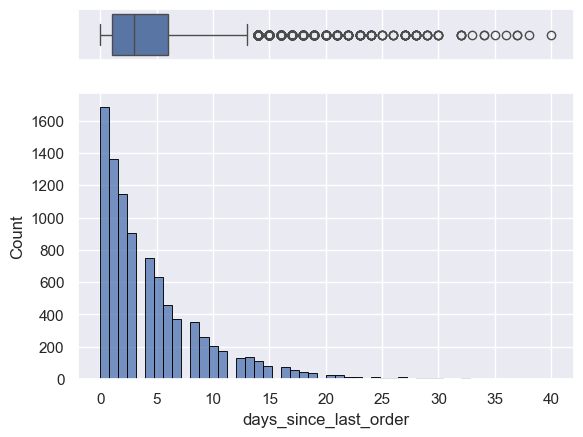

Описательные статистики для столбца  order_frequency_month :
count    9414.000000
mean        4.026623
std         2.832360
min         0.011046
25%         1.935428
50%         3.378769
75%         5.439363
max        27.389318
Name: order_frequency_month, dtype: float64


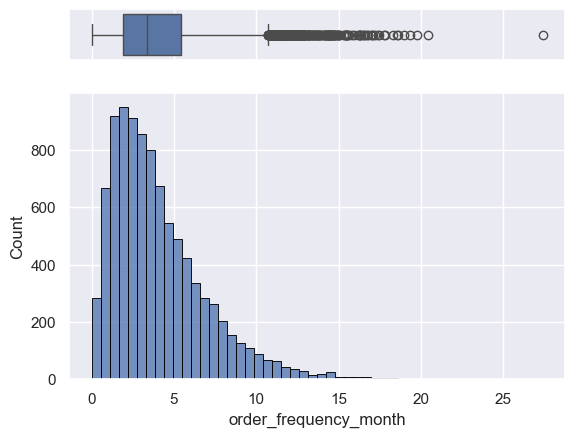

Описательные статистики для столбца  order_frequency_week :
count    9621.000000
mean        0.930277
std         0.658280
min        -0.169131
25%         0.445776
50%         0.783019
75%         1.257711
max         6.302624
Name: order_frequency_week, dtype: float64


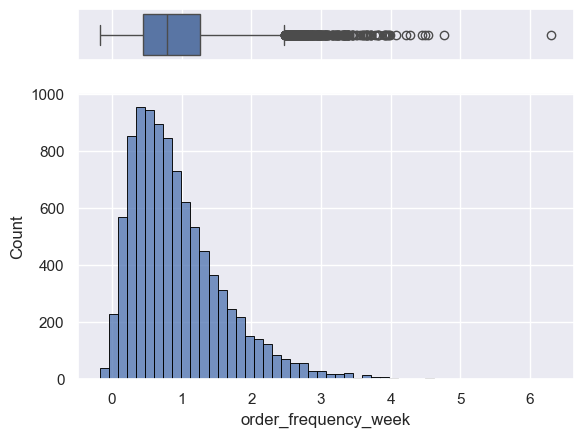

Описательные статистики для столбца  avg_order_value :
count    9437.000000
mean     1063.314941
std       707.334656
min       -32.075932
25%       552.875549
50%       898.554565
75%      1405.508545
max      5901.965332
Name: avg_order_value, dtype: float64


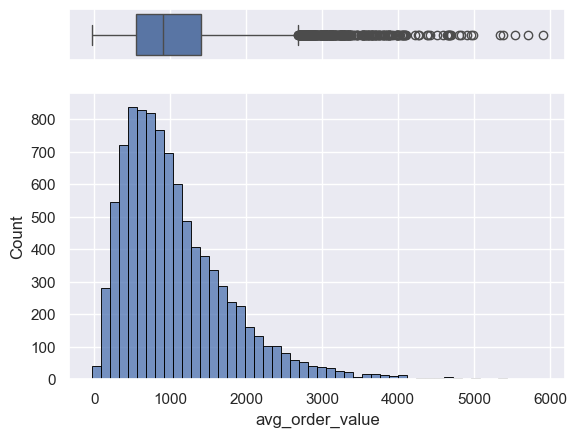

Описательные статистики для столбца  median_order_value :
count    9197.000000
mean      452.699615
std       259.007690
min       -10.353340
25%       263.719452
50%       405.859039
75%       591.417297
max      2189.101562
Name: median_order_value, dtype: float64


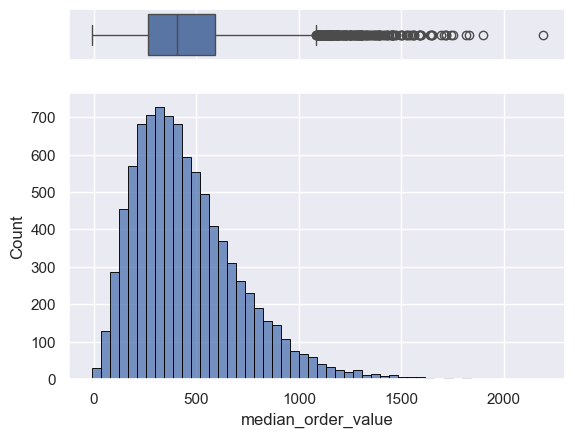

Описательные статистики для столбца  total_spent_last_month :
count     9708.000000
mean      1945.758845
std       2377.805345
min        -43.716463
25%        628.971321
50%       1294.345827
75%       2475.741150
max      79298.849570
Name: total_spent_last_month, dtype: float64


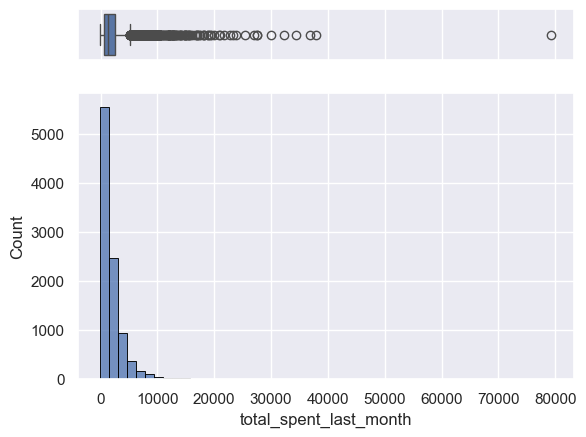

Описательные статистики для столбца  total_spent_last_week :
count    9086.000000
mean      412.849976
std       446.281097
min     -2290.559570
25%       136.326706
50%       287.148071
75%       549.371643
max      8615.989258
Name: total_spent_last_week, dtype: float64


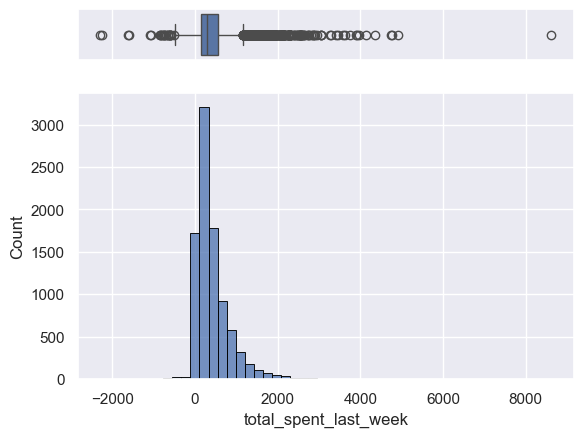

Описательные статистики для столбца  discount_usage_rate :
count    9613.000000
mean        0.283961
std         0.158734
min         0.002162
25%         0.159370
50%         0.263945
75%         0.387000
max         0.887301
Name: discount_usage_rate, dtype: float64


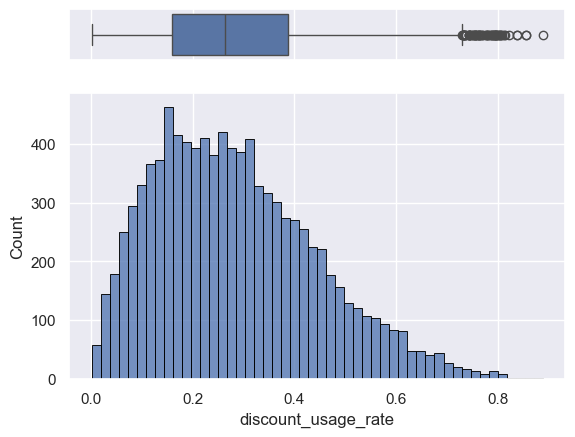

Описательные статистики для столбца  seasonal_menu_tried :
count    9048.000000
mean        0.699823
std         0.458349
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: seasonal_menu_tried, dtype: float64


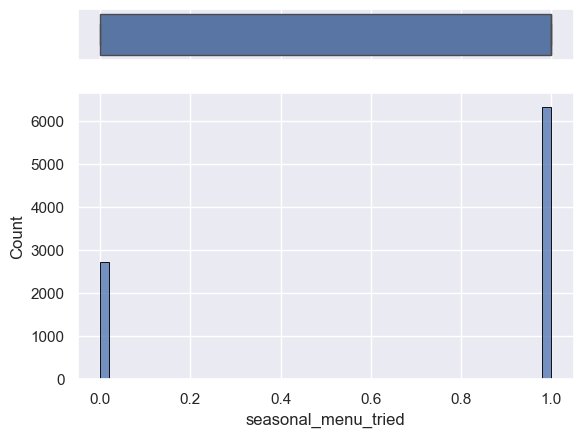

Описательные статистики для столбца  app_opens_per_week :
count    9138.000000
mean       11.327253
std        14.525064
min         0.000000
25%         6.337291
50%         9.221858
75%        12.714696
max       224.587875
Name: app_opens_per_week, dtype: float64


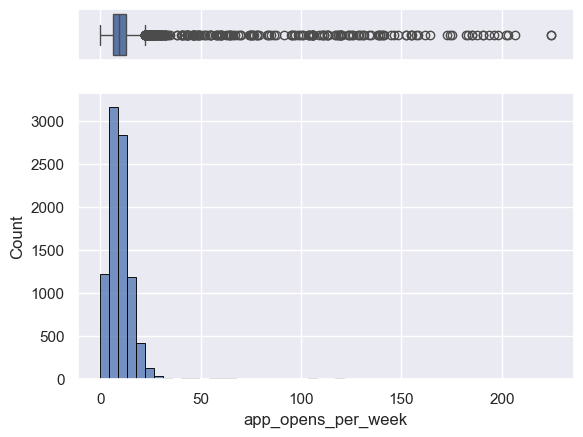

Описательные статистики для столбца  notifications_enabled :
count    9483.000000
mean        0.753032
std         0.431280
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: notifications_enabled, dtype: float64


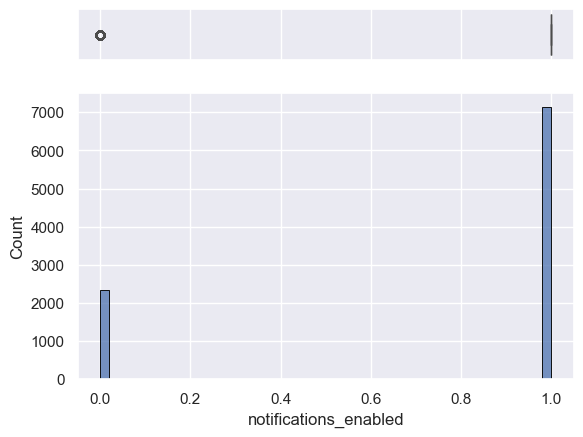

Описательные статистики для столбца  review_rating_last_10 :
count    9328.000000
mean        4.207880
std         0.781733
min         1.415526
25%         3.675496
50%         4.205958
75%         4.718441
max         7.384425
Name: review_rating_last_10, dtype: float64


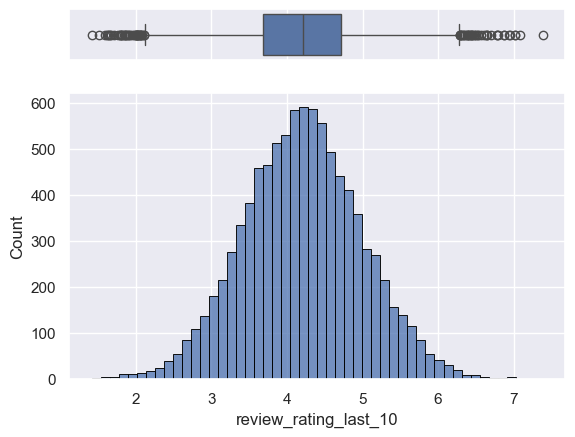

Описательные статистики для столбца  review_rating_last_1 :
count    9182.000000
mean        4.021422
std         1.206145
min        -0.897000
25%         3.215034
50%         3.988825
75%         4.844709
max         8.558442
Name: review_rating_last_1, dtype: float64


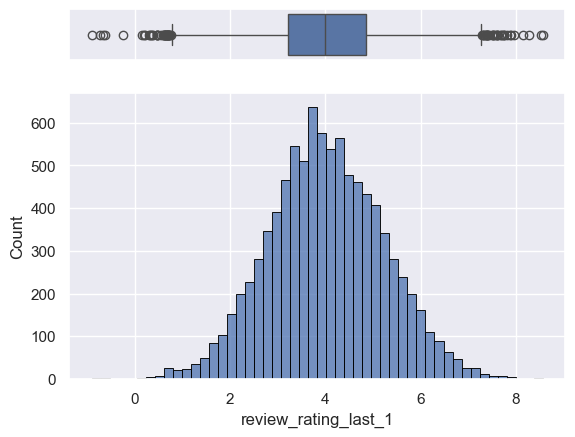

Описательные статистики для столбца  app_crashes_last_month :
count    9305.000000
mean        1.015905
std         1.011224
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         7.000000
Name: app_crashes_last_month, dtype: float64


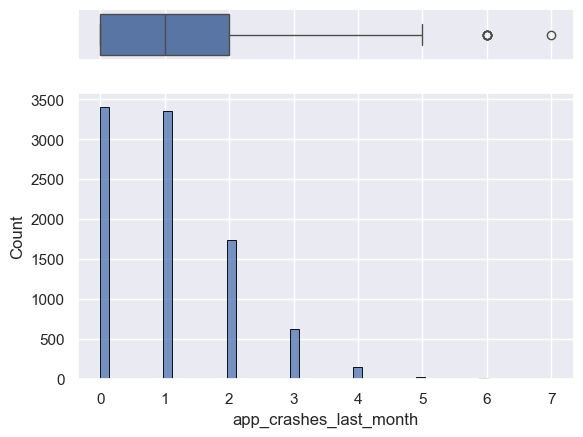

Описательные статистики для столбца  days_since_last_promo :
count    9299.000000
mean       14.559523
std        15.286203
min         0.000000
25%         4.000000
50%        10.000000
75%        20.000000
max       140.000000
Name: days_since_last_promo, dtype: float64


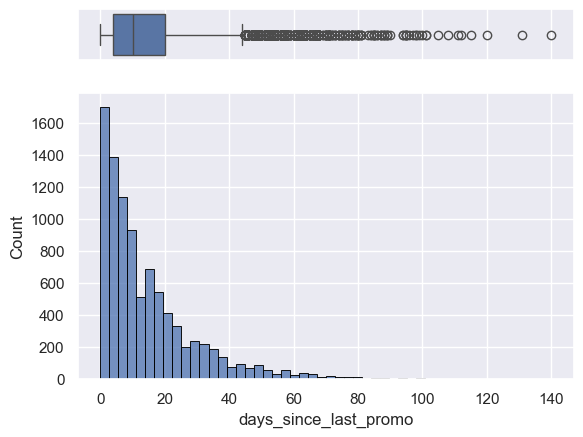

Описательные статистики для столбца  coffee_preference_change :
count    9414.000000
mean        0.193010
std         0.394671
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: coffee_preference_change, dtype: float64


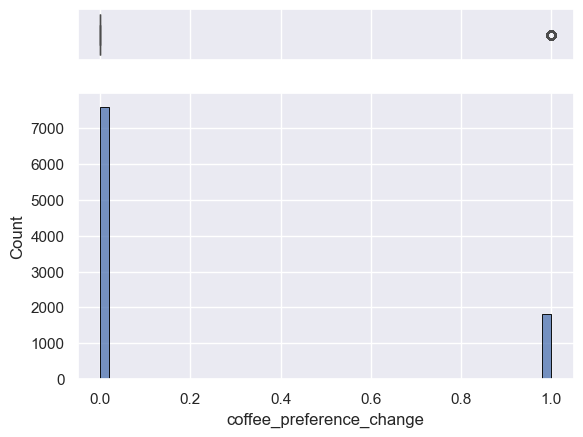

Описательные статистики для столбца  churn :
count    9995.000000
mean        0.060030
std         0.237554
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: churn, dtype: float64


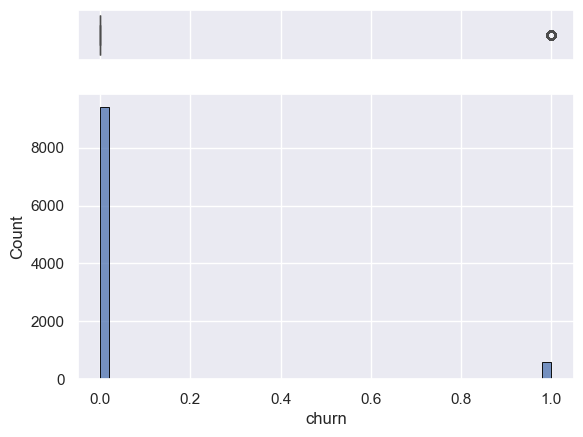

In [19]:
def feature_distribution (tmp0, value):
    '''
    Исследует распределение признаков по столбцам:
      Считает описательные статистики
      Строит гистограммы распределения, ящики с усами по столвцам/столбцу
    
    value - столбцы/столбец
    
    '''
    BOLD = '\033[1m' 
    RESET = '\033[0m'
    
    for col in value:
        print(f'Описательные статистики для столбца {BOLD} {col} {RESET}:')  # Заголовок отдельно
        print(tmp0[col].describe())
        sns.set_theme(style="darkgrid")
        # creating a figure composed of two matplotlib.Axes objects (ax_box and ax_hist)
        f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)})

        # assigning a graph to each ax
        sns.boxplot(data=tmp0, x=col, orient="h", ax=ax_box)  # Явно указываем data и x
        sns.histplot(data=tmp0, x=col, ax=ax_hist, bins=50, edgecolor='black')

        # Remove x axis name for the boxplot
        ax_box.set(xlabel='')
        plt.show()
    
feature_distribution (df, ['days_since_last_order', 'order_frequency_month', 'order_frequency_week', 
                       'avg_order_value', 'median_order_value', 'total_spent_last_month', 
                       'total_spent_last_week', 'discount_usage_rate', 'seasonal_menu_tried', 
                       'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 
                       'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 
                       'coffee_preference_change', 'churn'])

- days_since_last_order : есть пропуски, выбросы (Q3=6)
- order_frequency_month: Q3=5.4 есть выбросы. Норм, приемлемы
- order_frequency_week: есть отрицат числа, мин=-0,16 (возможно возвраты) Q3=1,26, макс=6.3, есть выбросы.  Норм, приемлемы
- avg_order_value: есть отрицат числа, мин=-32 (возможно возвраты) Q3=1405, макс=5901 есть выбросы. Норм, приемлемы
- median_order_value: есть отрицат числа, мин=-10 (возможно возвраты) Q3=591, макс=2189 есть выбросы. Норм, приемлемы
- total_spent_last_month: есть отрицат числа, мин=-43 (возможно возвраты) Q3=2475, макс=79298 есть выбросы. Очень разнородные данные!
- total_spent_last_week: есть отрицат числа, мин=-2290 (возможно возвраты) Q3=549, макс=8615 есть выбросы. Очень разнородные данные!
- discount_usage_rate: Q3=0.39 есть выбросы. Норм, приемлемы
- seasonal_menu_tried: бинарные значения, все норм
- app_opens_per_week: мин=0  Q3=12,7, макс=224 есть выбросы. Норм, приемлемы
- notifications_enabled: бинарные значения, все норм
- review_rating_last_10: близко к нормальному распределению
- review_rating_last_1: есть отрицат числа, близко к нормальному распределению
- app_crashes_last_month: 7 категорий норм
- days_since_last_promo: Q3=20, макс=140 есть выбросы. Норм, приемлемы
- coffee_preference_change: бинарные значения, все норм
- churn: бинарные значения, все норм "1" очень мало, надо определить процент, исследовать распределение в разрезе других признаков

### Определим выбросы в столбцах по методу IQR

In [20]:
def detect_outliers_iqr(tmp0, down, app):
    """
    Определяет в датафрейме числовые столбцы, ищет в них выбросы с помощью метода IQR.
    Затем ограничивает данные по процентам: down — нижний порог, app — верхний.

    Параметры:
    tmp0 — датафрейм.
    down — нижний процентиль для ограничения данных (например, 0.01 = 1%).
    app — верхний процентиль для ограничения (например, 0.99 = 99%).
    
    пример вызова:
    df2, outliers_data = detect_outliers_iqr(df, 0.01, 0.99)
    """
    outliers_info = {}

    for column in tmp0.columns:
        if np.issubdtype(tmp0[column].dtype, np.number):
            # Шаг 1: ищем выбросы методом IQR
            Q1 = tmp0[column].quantile(0.25)
            Q3 = tmp0[column].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound_iqr = Q1 - 1.5 * IQR  # Нижняя граница IQR
            upper_bound_iqr = Q3 + 1.5 * IQR  # Верхняя граница IQR

            # Находим индексы выбросов по IQR
            outliers = tmp0[(tmp0[column] < lower_bound_iqr) | (tmp0[column] > upper_bound_iqr)].index

            if len(outliers) > 0:
                outliers_info[column] = {
                    'outlier_indices': outliers,
                    'lower_bound_IQR': lower_bound_iqr,
                    'upper_bound_IQR': upper_bound_iqr,
                    'count': len(outliers),
                    'percentile_lower': down,
                    'percentile_upper': app
                }
                print(f"Столбец '{column}': найдено {len(outliers)} выбросов (IQR). "
                      f"Границы IQR: [{lower_bound_iqr:.2f}, {upper_bound_iqr:.2f}]")
            else:
                print(f"Столбец '{column}': выбросов по IQR не найдено.")

            # Шаг 2: ограничиваем данные по процентилям
            lower_percentile = tmp0[column].quantile(down)  # например, 1%
            upper_percentile = tmp0[column].quantile(app)  # например, 99%

            tmp0 = tmp0[
                (tmp0[column] >= lower_percentile) &
                (tmp0[column] <= upper_percentile)
            ].copy()

    # Выводим итоговое число столбцов с выбросами
    print(f'\nЧисло столбцов-выбросов (по IQR): {len(outliers_info)}')
    print(f'Данные ограничены по процентилям: нижний — {down:.2%}, верхний — {app:.2%}')

    return tmp0, outliers_info

df2, outliers_data = detect_outliers_iqr(df, 0.01, 0.99)

Столбец 'days_since_last_order': найдено 535 выбросов (IQR). Границы IQR: [-6.50, 13.50]
Столбец 'order_frequency_month': найдено 264 выбросов (IQR). Границы IQR: [-3.34, 10.70]
Столбец 'order_frequency_week': найдено 180 выбросов (IQR). Границы IQR: [-0.75, 2.45]
Столбец 'avg_order_value': найдено 247 выбросов (IQR). Границы IQR: [-730.14, 2684.53]
Столбец 'median_order_value': найдено 105 выбросов (IQR). Границы IQR: [-215.34, 1068.71]
Столбец 'total_spent_last_month': найдено 335 выбросов (IQR). Границы IQR: [-1872.34, 4932.79]
Столбец 'total_spent_last_week': найдено 296 выбросов (IQR). Границы IQR: [-409.77, 1089.69]
Столбец 'discount_usage_rate': найдено 34 выбросов (IQR). Границы IQR: [-0.18, 0.72]
Столбец 'seasonal_menu_tried': выбросов по IQR не найдено.
Столбец 'app_opens_per_week': найдено 126 выбросов (IQR). Границы IQR: [-2.93, 21.78]
Столбец 'notifications_enabled': найдено 979 выбросов (IQR). Границы IQR: [1.00, 1.00]
Столбец 'review_rating_last_10': найдено 31 выбросов 

In [21]:
count_otr=df[df['total_spent_last_month']<=0]
print(len(count_otr))

2


Проверим количество и долю отрицат записей в полях: `['order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'review_rating_last_1']`

In [22]:
for col in ['order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month',
           'total_spent_last_week', 'review_rating_last_1']:
    df_otr=df[df[col]<0]
    df_otr.shape[0]
    procent=round(df_otr.shape[0]/df.shape[0], 5)
    print(f'в столбце {col} число отрица записей: {df_otr.shape[0]}, доля отрицат записей: {procent}')

в столбце order_frequency_week число отрица записей: 74, доля отрицат записей: 0.0074
в столбце avg_order_value число отрица записей: 2, доля отрицат записей: 0.0002
в столбце median_order_value число отрица записей: 2, доля отрицат записей: 0.0002
в столбце total_spent_last_month число отрица записей: 2, доля отрицат записей: 0.0002
в столбце total_spent_last_week число отрица записей: 160, доля отрицат записей: 0.01601
в столбце review_rating_last_1 число отрица записей: 5, доля отрицат записей: 0.0005


In [23]:
for col in ['review_rating_last_1']:
    df = df[df[col]>=0]

В полях `'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week'`, может быть и нет ошибочных значений. Возможно отрицательные значения означают **возвраты*** заказов. Однако, нас интересуют продажи, поэтому **удалим отрицательные значения в поле review_rating_last_1**.

В поле `eview_rating_last_1` (оценка последнего на момент сбора данных заказа клиента), 5 записей с отрицательными значениями - явно ошибка, поскольку отрицательной оценка не может быть. 

**Удалим 5** записей в поле `eview_rating_last_1`. 

**Проверка, сколько отрицательных значений осталось.**

Осталось **0** записей, замена прошла.

**Заменим отрицательные значения на 1e-10**

In [24]:
columns_to_clip=['order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month',
           'total_spent_last_week', 'review_rating_last_1']
df[columns_to_clip] = df[columns_to_clip].clip(lower=1e-10)

ПРоверка. Отрицательные значения заменили

In [25]:
df['order_frequency_week'].describe()

count    8.828000e+03
mean     9.290884e-01
std      6.534677e-01
min      1.000000e-10
25%      4.457119e-01
50%      7.827039e-01
75%      1.255306e+00
max      6.302624e+00
Name: order_frequency_week, dtype: float64

### Отработка пропусков

In [26]:
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]

    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    return missing_stats  # убрали стилизацию

show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
days_since_last_order,823,0.089681
order_frequency_month,531,0.057862
order_frequency_week,349,0.038030
avg_order_value,515,0.056119
median_order_value,730,0.079547
total_spent_last_month,256,0.027896
total_spent_last_week,832,0.090661
discount_usage_rate,344,0.037485
last_coffee_type,230,0.025063
preferred_roast,100,0.010897


In [27]:
df.shape[0]

9177

**Поскольку числовые поля датафрейма разнородные и содержат выбросы, то заполним пропуски в числовых полях медианными значениями**, но **НЕ бинарные** (seasonal_menu_tried, notifications_enabled, coffee_preference_change) признаки:

In [28]:
for col in ['days_since_last_order', 'order_frequency_month', 'order_frequency_week', 
                       'avg_order_value', 'median_order_value', 'total_spent_last_month', 
                       'total_spent_last_week', 'discount_usage_rate', 'app_opens_per_week', 'review_rating_last_10', 
                       'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo']:
    df[col] = df[col].fillna(df[col].median())      

Построим распределения снова, на очищенных данных

Проверка пропусков:

In [29]:
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return missing_stats  # убрали стилизацию

show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
last_coffee_type,230,0.025063
preferred_roast,100,0.010897
milk_preference,584,0.063637
seasonal_menu_tried,868,0.094584
coffee_bean_origin,586,0.063855
last_drink_size,450,0.049036
subscription_status,804,0.087610
notifications_enabled,463,0.050452
seasons,596,0.064945
phone_type,300,0.032690


В категориальных полях `preferred_roast` и `geo_location` удалим пропуски. потому что  в сумме на долю этих пропусков приходится около  **1%** (192) записей.

In [30]:
df=df.dropna(subset=['preferred_roast', 'geo_location'])

In [31]:
df.shape[0]

8985

In [32]:
procent=round(df.dropna(subset=['preferred_roast', 'geo_location']).shape[0]/df.shape[0], 5)
display(f'Удалено 192 ({procent}%) записи. В датафрейме df 9177 запись')

'Удалено 192 (1.0%) записи. В датафрейме df 9177 запись'

Пропуски остались в **категориальных и бинарных** столбцах. Удалить эту информацию - плохо её много, оставить - плохо, модель не качественная будет.

Решено **заменить** в этих столбках **пропуски** на индикатор: **"-1"**, тогда в модели эта информация тоже может использоваться.

In [33]:
for col in ['last_coffee_type', 'preferred_roast', 'milk_preference', 
                           'seasonal_menu_tried', 'coffee_bean_origin', 'last_drink_size', 
                           'subscription_status', 'notifications_enabled', 'seasons', 'phone_type', 
                           'coffee_preference_change', 'geo_location']:
    df[col] = df[col].fillna('-1')

In [34]:
show_missing_stats(df)

'Пропусков в данных нет'

In [35]:
df.columns

Index(['user_id', 'days_since_last_order', 'order_frequency_month',
       'order_frequency_week', 'avg_order_value', 'median_order_value',
       'total_spent_last_month', 'total_spent_last_week',
       'discount_usage_rate', 'last_coffee_type', 'preferred_roast',
       'milk_preference', 'seasonal_menu_tried', 'coffee_bean_origin',
       'last_drink_size', 'subscription_status', 'app_opens_per_week',
       'notifications_enabled', 'review_rating_last_10',
       'review_rating_last_1', 'app_crashes_last_month', 'seasons',
       'days_since_last_promo', 'phone_type', 'coffee_preference_change',
       'geo_location', 'churn'],
      dtype='object')

Описательные статистики для столбца  days_since_last_order :
count    8985.000000
mean        4.264775
std         4.637666
min         0.000000
25%         1.000000
50%         3.000000
75%         6.000000
max        40.000000
Name: days_since_last_order, dtype: float64


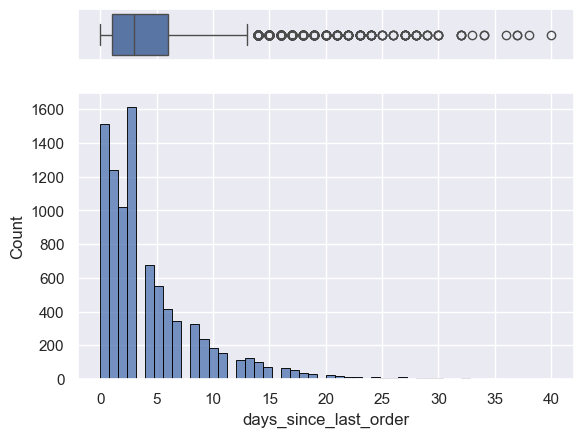

Описательные статистики для столбца  order_frequency_month :
count    8985.000000
mean        3.984922
std         2.742571
min         0.011046
25%         2.019302
50%         3.380509
75%         5.273773
max        27.389318
Name: order_frequency_month, dtype: float64


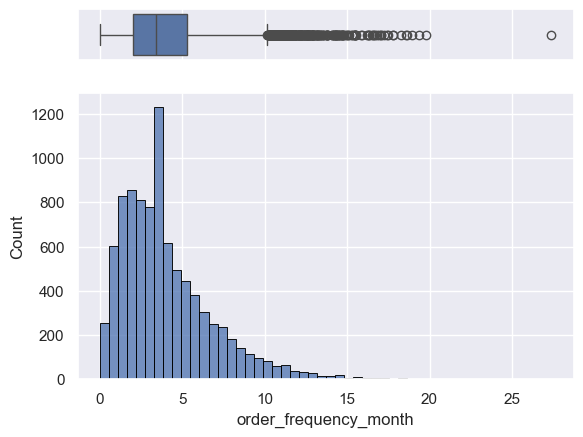

Описательные статистики для столбца  avg_order_value :
count    8.985000e+03
mean     1.055362e+03
std      6.929829e+02
min      1.000000e-10
25%      5.700618e+02
50%      8.974253e+02
75%      1.366409e+03
max      5.901965e+03
Name: avg_order_value, dtype: float64


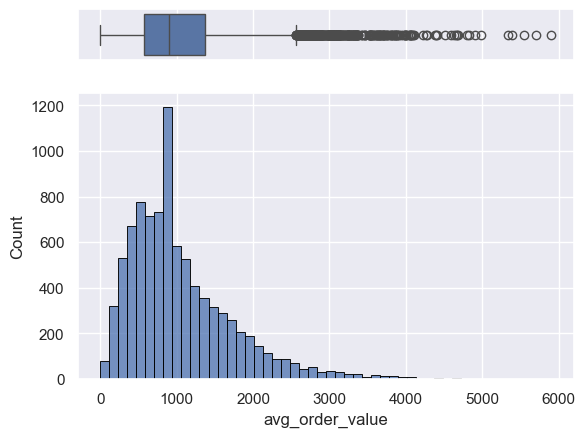

Описательные статистики для столбца  median_order_value :
count    8.985000e+03
mean     4.492616e+02
std      2.501046e+02
min      1.000000e-10
25%      2.748754e+02
50%      4.066815e+02
75%      5.714295e+02
max      2.189102e+03
Name: median_order_value, dtype: float64


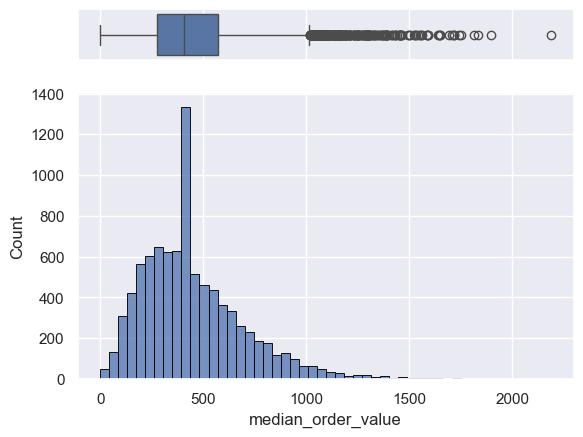

Описательные статистики для столбца  total_spent_last_month :
count    8.985000e+03
mean     1.917922e+03
std      2.219802e+03
min      1.000000e-10
25%      6.422911e+02
50%      1.292966e+03
75%      2.418589e+03
max      3.796568e+04
Name: total_spent_last_month, dtype: float64


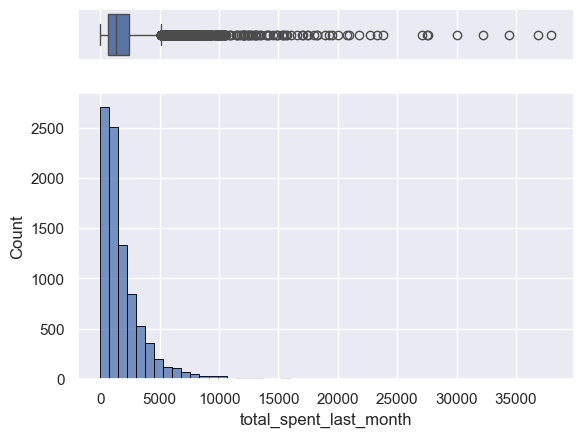

Описательные статистики для столбца  discount_usage_rate :
count    8985.000000
mean        0.282114
std         0.155349
min         0.002162
25%         0.162183
50%         0.263069
75%         0.380096
max         0.887301
Name: discount_usage_rate, dtype: float64


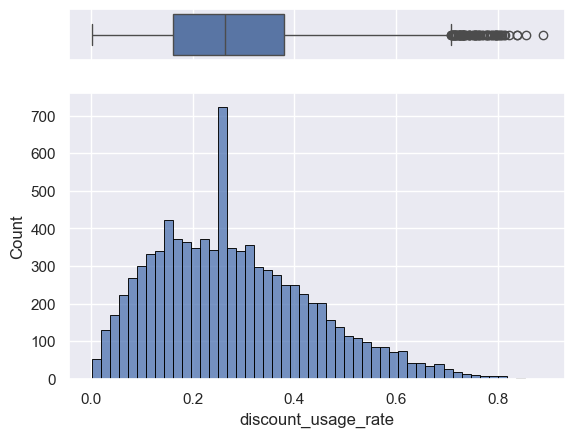

Описательные статистики для столбца  app_opens_per_week :
count    8985.000000
mean       11.140767
std        13.918131
min         0.000000
25%         6.623375
50%         9.234037
75%        12.329505
max       224.587875
Name: app_opens_per_week, dtype: float64


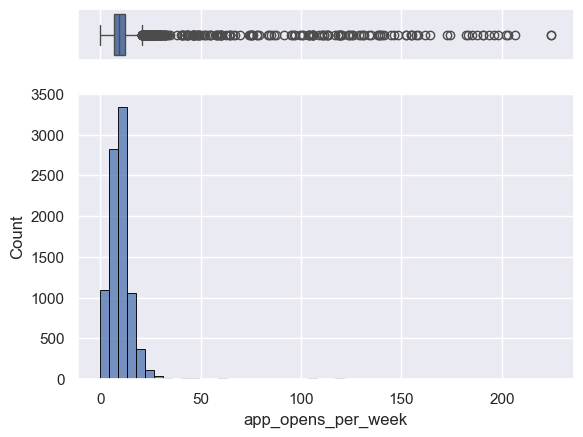

Описательные статистики для столбца  review_rating_last_10 :
count    8985.000000
mean        4.205659
std         0.754355
min         1.415526
25%         3.723893
50%         4.197306
75%         4.675785
max         7.384425
Name: review_rating_last_10, dtype: float64


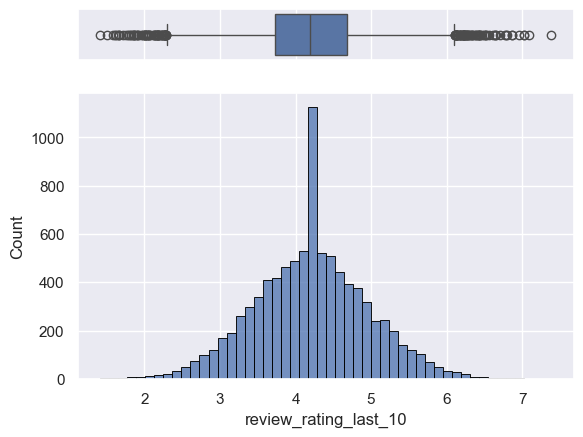

Описательные статистики для столбца  app_crashes_last_month :
count    8985.000000
mean        1.013690
std         0.975121
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         7.000000
Name: app_crashes_last_month, dtype: float64


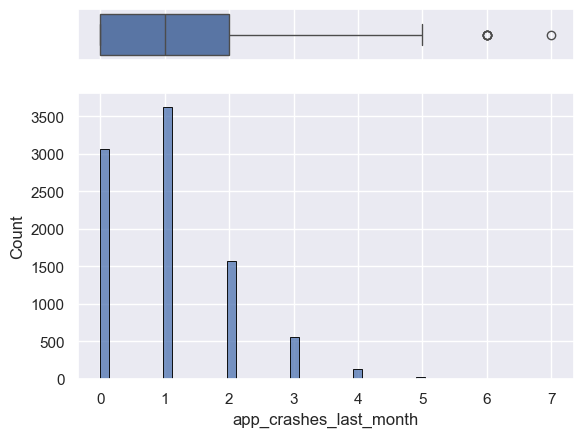

Описательные статистики для столбца  days_since_last_promo :
count    8985.000000
mean       14.167390
std        14.642372
min         0.000000
25%         4.000000
50%        10.000000
75%        19.000000
max       140.000000
Name: days_since_last_promo, dtype: float64


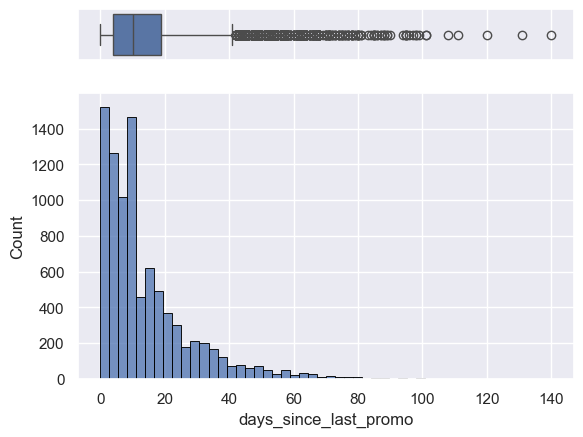

Описательные статистики для столбца  churn :
count    8985.000000
mean        0.059544
std         0.236653
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: churn, dtype: float64


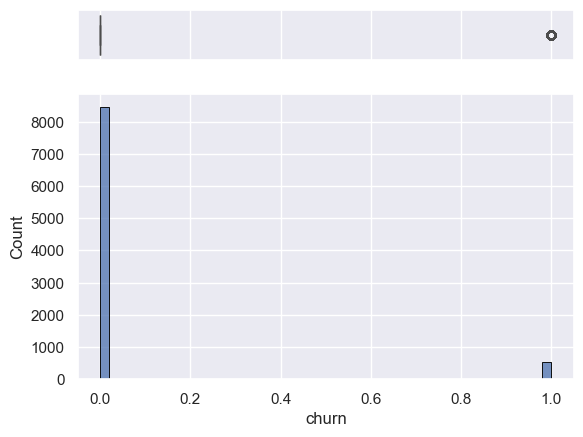

In [36]:
def feature_distribution (tmp0, value):
    '''
    Исследует распределение признаков по столбцам:
      Считает описательные статистики
      Строит гистограммы распределения, ящики с усами по столвцам/столбцу
    
    value - столбцы/столбец
    
    '''
    BOLD = '\033[1m' 
    RESET = '\033[0m'
    
    for col in value:
        print(f'Описательные статистики для столбца {BOLD} {col} {RESET}:')  # Заголовок отдельно
        print(tmp0[col].describe())
        sns.set_theme(style="darkgrid")
        # creating a figure composed of two matplotlib.Axes objects (ax_box and ax_hist)
        f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)})

        # assigning a graph to each ax
        sns.boxplot(data=tmp0, x=col, orient="h", ax=ax_box)  # Явно указываем data и x
        sns.histplot(data=tmp0, x=col, ax=ax_hist, bins=50, edgecolor='black')

        # Remove x axis name for the boxplot
        ax_box.set(xlabel='')
        plt.show()
    
feature_distribution (df, ['days_since_last_order', 'order_frequency_month', 
                       'avg_order_value', 'median_order_value', 'total_spent_last_month', 
                       'discount_usage_rate', 'app_opens_per_week',  
                           'review_rating_last_10', 
                       'app_crashes_last_month', 'days_since_last_promo', 
                        'churn'])

Таким образом: 
- данные изучили
- дубликаты выявили, удалили
- категориальные столбцы изучили, нормаллизовали. Пропуски оставили без изменений
- числовые столбцы: изучили распределениея, обработали отрицательные значения и пропуски:
      - в непрерывных данных пропуски заменили медианными значениями
      - в бинарных (`seasonal_menu_tried, notifications_enabled, coffee_preference_change`) - пропуски оставили без изменений

Обработка данных завершена

In [37]:
df.shape[0]

8985

### Изучаем распределение churn для признаков: 


Churn: перестал ли пользователь пользоваться сервисом geo_location:
                  mean  count
geo_location                 
geo_2         0.069236   1401
geo_99        0.056604    106
geo_3         0.056163   1371
geo_1         0.051724   1334


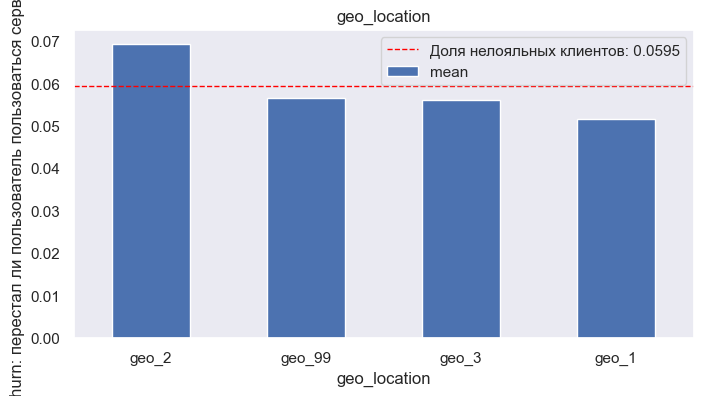


Churn: перестал ли пользователь пользоваться сервисом preferred_roast:
                     mean  count
preferred_roast                 
medium           0.059706   2998
dark             0.059616   2969
light            0.059311   3018


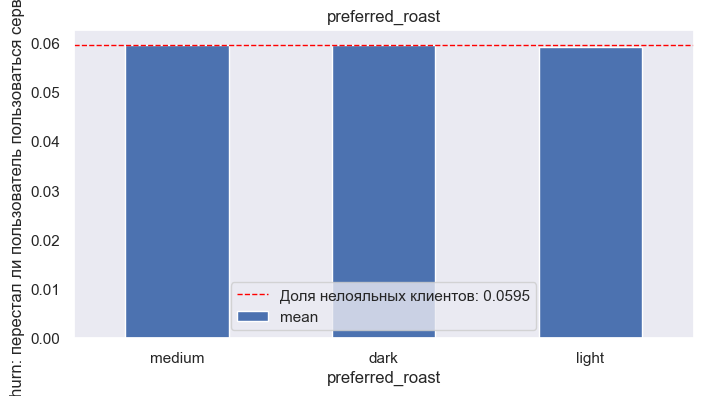


Churn: перестал ли пользователь пользоваться сервисом seasons:
             mean  count
seasons                 
-1       0.078767    584
spring   0.061072   2145
autumn   0.057784   2094
winter   0.057007   2105
summer   0.056879   2057


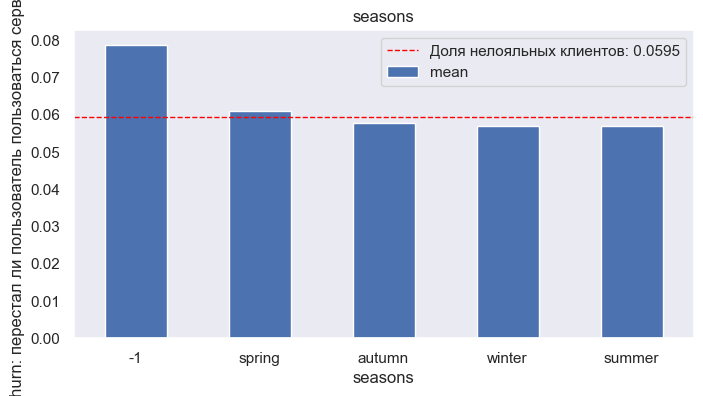


Churn: перестал ли пользователь пользоваться сервисом subscription_status:
                         mean  count
subscription_status                 
pro                  0.102922    787
premium              0.073333   1650
-1                   0.053165    790
basic                0.052354   2464
none                 0.049180   3294


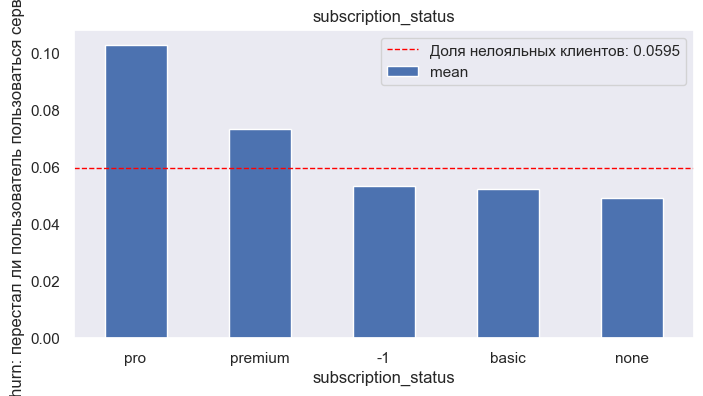


Churn: перестал ли пользователь пользоваться сервисом phone_type:
                mean  count
phone_type                 
android     0.063548   3997
web         0.058195    842
ios         0.057313   3856
-1          0.037931    290


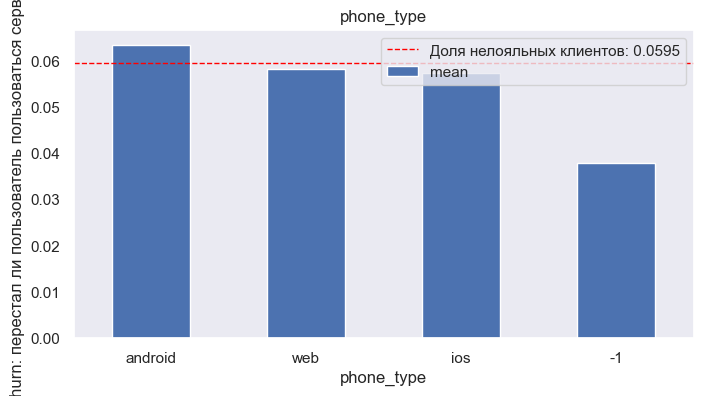


Churn: перестал ли пользователь пользоваться сервисом last_coffee_type:
                      mean  count
last_coffee_type                 
-1                0.075893    224
robusta           0.068046   2175
blend             0.058245   1322
arabica           0.055661   5264


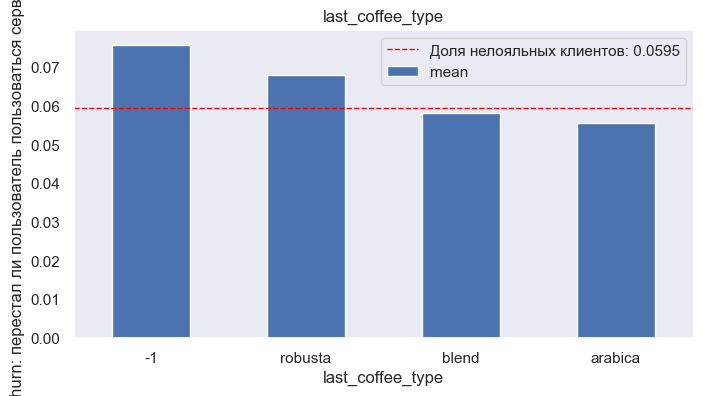


Churn: перестал ли пользователь пользоваться сервисом last_drink_size:
                     mean  count
last_drink_size                 
-1               0.084282    439
large            0.060039   2565
medium           0.057995   4259
small            0.056330   1722


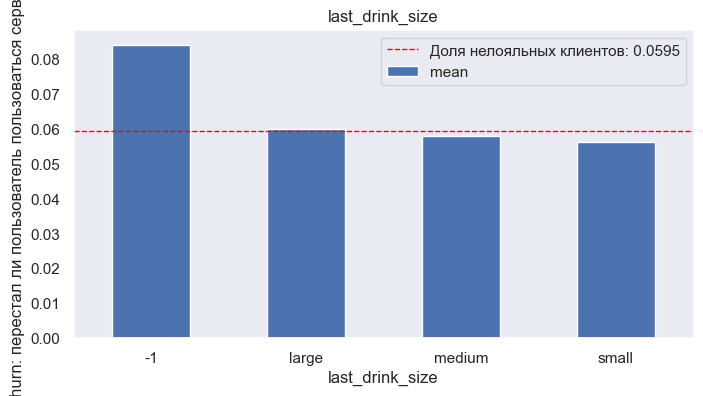


Churn: перестал ли пользователь пользоваться сервисом milk_preference:
                     mean  count
milk_preference                 
almond           0.065098   1275
whole            0.064087   2481
-1               0.063380    568
oat              0.057738   1680
soy              0.055687    844
skim             0.053302   1257
none             0.052273    880


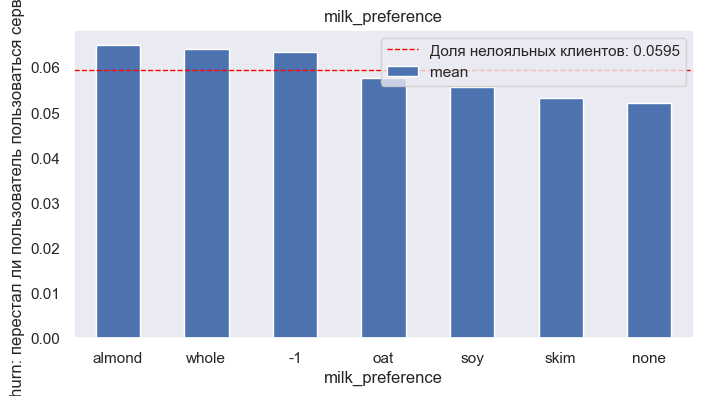


Churn: перестал ли пользователь пользоваться сервисом coffee_bean_origin:
                        mean  count
coffee_bean_origin                 
brazil              0.063181   1377
-1                  0.061189    572
ethiopia            0.061069   1441
colombia            0.060178   1346
guatemala           0.059744   1406
vietnam             0.057042   1420
kenya               0.055517   1423


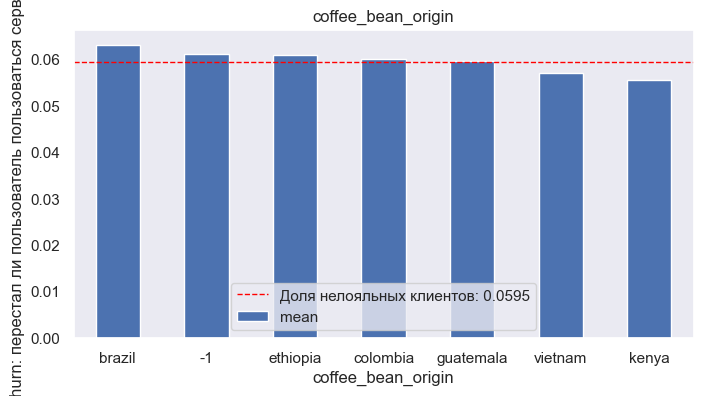

In [38]:
def explorer_cat(tmp0, churn, value, title_churn):
    """
    Функция работает с категориальными столбцами.
    Строит таблицу по признакам категории, считает их долю и количество по убыванию.
    Отображает на столбчатой диаграмме: ось X — распределение признаков категориальной переменной,
    ось Y — доля бинарного признака (например, churn), распределение которого смотрим по категориальным столбцам.

    Параметры:
    tmp0 — датафрейм
    churn — бинарный признак, распределение которого смотрим
    value — список категориальных столбцов
    title_churn — заголовок для графиков
    """

    for col in value:
        # Группируем по категориальному столбцу, считаем среднее и количество
        grouped = tmp0.groupby(col)
        share = grouped[churn].agg(['mean', 'count'])

        # Фильтруем записи с малым числом пользователей и сортируем
        sorted_share = share[share['count'] > 100].sort_values('mean', ascending=False)

        print(f"\n{'=' * 60}")
        print(f"{title_churn} {col}:")
        print('=' * 60)
        print(sorted_share)

        n_categories = len(sorted_share.index)

        if n_categories < 10:
            # Вертикальная столбчатая диаграмма
            plt.figure(figsize=(8, 4))
            sorted_share['mean'].plot(
                kind='bar',
                rot=0,
                legend=False,
                title=f'{col}'
            )
            plt.axhline(tmp0[churn].mean(), color='red', linestyle='--', linewidth=1,
                       label=f'Доля нелояльных клиентов: {round(tmp0[churn].mean(), 4)}')
            plt.xlabel(col)
            plt.ylabel(title_churn)

        else:
            # Горизонтальная столбчатая диаграмма (первые 10 категорий)
            plt.figure(figsize=(8, 6))
            sorted_share['mean'].head(10).plot(
                kind='barh',
                rot=0,
                legend=False,
                title=f'{col} (топ-10 по доле {title_churn})'
            )
            plt.axvline(tmp0[churn].mean(), color='red', linestyle='--', linewidth=1,
                     label=f'Доля нелояльных клиентов: {round(tmp0[churn].mean(), 4)}')
            plt.xlabel('Доля ' + title_churn)
            plt.ylabel(col)

        plt.grid()
        plt.legend()
        plt.show()

# Пример вызова
explorer_cat(
    df,
    'churn',
    ['geo_location', 'preferred_roast', 'seasons', 'subscription_status',
     'phone_type', 'last_coffee_type', 'last_drink_size',
     'milk_preference', 'coffee_bean_origin'],
    'Churn: перестал ли пользователь пользоваться сервисом'
)
 

### Корреляции между признаками

interval columns not set, guessing: ['days_since_last_order', 'order_frequency_month', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'discount_usage_rate', 'app_opens_per_week', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'churn']


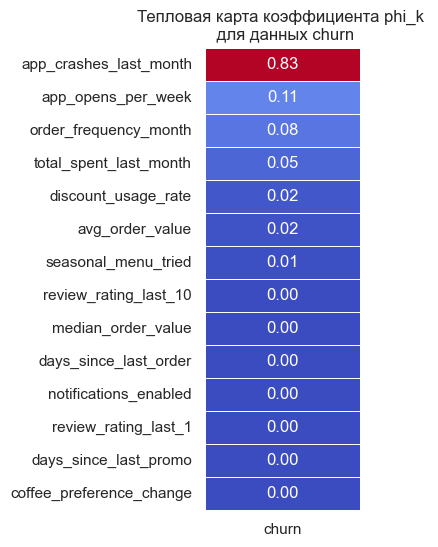

In [39]:
def correl_matrix_column(value, col):
    '''
    Строит тепловую карту по корреляционной матрицы для заданной переменной 
    value - столбцы/столбец
    col- столбец, для которого выводят коэффициенты корреляции
    '''
    correlation_matrix = df[value].phik_matrix()
    
    # Строим тепловую карту
    plt.figure(figsize=(2, 6))
    correlation_matrix.loc[correlation_matrix.index != col][[col]].sort_values(by=col, ascending=False)
    # Сохраняем матрицу корреляции признака col с другими признаками 
    data_heatmap = correlation_matrix.loc[correlation_matrix.index != col][[col]].sort_values(by=col, ascending=False)
    sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )
    # Добавляем заголовок и подпись по оси Х
    plt.title(f'Тепловая карта коэффициента phi_k \n для данных {col}')
    # Выводим график
    plt.show()
    


correl_matrix_column(['days_since_last_order', 'order_frequency_month',  
                       'avg_order_value', 'median_order_value', 'total_spent_last_month', 
                        'discount_usage_rate', 'seasonal_menu_tried', 
                       'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 
                       'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 
                       'coffee_preference_change', 'churn'], 'churn')

Обнаружена сильная взаимосвязь **0.83** `chorn` от `app_crashes_last_month` (сколько раз приложение зависало за последний месяц)

In [40]:
columns_to_analyze = [
    'days_since_last_order', 'order_frequency_month', 
    'avg_order_value', 'median_order_value', 'total_spent_last_month',
    'discount_usage_rate', 'last_coffee_type',
    'preferred_roast', 'milk_preference', 'seasonal_menu_tried',
    'coffee_bean_origin', 'last_drink_size', 'subscription_status',
    'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10',
    'review_rating_last_1', 'app_crashes_last_month', 'seasons',
    'days_since_last_promo', 'phone_type', 'coffee_preference_change',
    'geo_location', 'churn'
]

correlation_matrix = df[columns_to_analyze].phik_matrix()
display(correlation_matrix)

interval columns not set, guessing: ['days_since_last_order', 'order_frequency_month', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'discount_usage_rate', 'app_opens_per_week', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'churn']


,days_since_last_order,order_frequency_month,avg_order_value,median_order_value,total_spent_last_month,discount_usage_rate,last_coffee_type,preferred_roast,milk_preference,seasonal_menu_tried,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
days_since_last_order,1.000000,0.000000,0.000000,0.000000,0.000000,0.030996,0.000000,0.027532,0.000000,0.035816,...,0.035200,0.000000,0.057311,0.000000,0.000000,0.000000,0.016511,0.000000,0.010915,0.000000
order_frequency_month,0.000000,1.000000,0.000000,0.106972,0.453622,0.000000,0.000000,0.000000,0.000000,0.031769,...,0.000000,0.020748,0.000000,0.023922,0.000000,0.000000,0.000000,0.014559,0.125626,0.080665
avg_order_value,0.000000,0.000000,1.000000,0.873245,0.352062,0.025892,0.000000,0.000000,0.000000,0.024690,...,0.000000,0.000000,0.000000,0.025725,0.000000,0.000000,0.000000,0.000000,0.084117,0.016143
median_order_value,0.000000,0.106972,0.873245,1.000000,0.628326,0.000000,0.014701,0.000000,0.025654,0.030560,...,0.000000,0.000000,0.000000,0.006871,0.013321,0.000000,0.011113,0.000000,0.000000,0.000000
total_spent_last_month,0.000000,0.453622,0.352062,0.628326,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.049949
discount_usage_rate,0.030996,0.000000,0.025892,0.000000,0.000000,1.000000,0.000000,0.014139,0.023600,0.029637,...,0.000000,0.000000,0.000000,0.000000,0.029129,0.000000,0.000000,0.000000,0.071704,0.021523
last_coffee_type,0.000000,0.000000,0.000000,0.014701,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.024723,0.009498,0.032894,0.000000,0.032666,0.000000,0.006703,0.000000,0.024353
preferred_roast,0.027532,0.000000,0.000000,0.000000,0.000000,0.014139,0.000000,1.000000,0.000000,0.000000,...,0.009942,0.039106,0.000000,0.000000,0.000000,0.000000,0.023976,0.000000,0.050894,0.000000
milk_preference,0.000000,0.000000,0.000000,0.025654,0.000000,0.023600,0.000000,0.000000,1.000000,0.000000,...,0.007429,0.046583,0.000000,0.015761,0.031816,0.020588,0.029773,0.000000,0.038499,0.000000
seasonal_menu_tried,0.035816,0.031769,0.024690,0.030560,0.000000,0.029637,0.000000,0.000000,0.000000,1.000000,...,0.074625,0.037508,0.041091,0.046324,0.000000,0.000000,0.000000,0.000000,0.000000,0.007353


- `order_frequency_month` и `total_spent_last_month` (0,45), `total_spent_last_week` (0,43)
- `avg_order_value` и `median_order_value` (0,87), `total_spent_last_month` (0,35)
- `median_order_value` и `total_spent_last_month` (0,63)
- `total_spent_last_month`	 и `order_frequency_month` (0,45), `avg_order_value` (0,35), `median_order_value` (0,63) , `app_opens_per_week` (0,65)
- `subscription_status` и `app_opens_per_week` (0,24) 


`total_spent_last_week` и `order_frequency_week, review_rating_last_1`  - **удалить**, дублируют `total_spent_last_month` и `order_frequency_month`, `review_rating_last_10` 


Не выявлено взаимосвязей для признаков:

`'days_since_last_order', 'discount_usage_rate', 'last_coffee_type', 'preferred_roast', 'milk_preference', 'seasonal_menu_tried', 'coffee_bean_origin', 'last_drink_size', 'notifications_enabled'`

**Удаляем стоблцы**

In [41]:
df=df.drop(columns=['user_id', 'order_frequency_week', 'total_spent_last_week', 'review_rating_last_1'])

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8985 entries, 1128 to 7457
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     8985 non-null   float32
 1   order_frequency_month     8985 non-null   float32
 2   avg_order_value           8985 non-null   float32
 3   median_order_value        8985 non-null   float32
 4   total_spent_last_month    8985 non-null   float64
 5   discount_usage_rate       8985 non-null   float32
 6   last_coffee_type          8985 non-null   object 
 7   preferred_roast           8985 non-null   object 
 8   milk_preference           8985 non-null   object 
 9   seasonal_menu_tried       8985 non-null   object 
 10  coffee_bean_origin        8985 non-null   object 
 11  last_drink_size           8985 non-null   object 
 12  subscription_status       8985 non-null   object 
 13  app_opens_per_week        8985 non-null   float32
 14  notificati

В датафрейме **8985** строк и **23** столбца

### Выводы по этапу 2. Первичный анализ данных
1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.
   - Датафрейм содержит: строк - **10450**, столбцов - **27**. Названия столбцов датафрейма приведены к стилю snake case. Столбцов типа **float: 16**. Столбцов типа **object: 10**. Столбцов типа **int: 1**.
   - Типы данных представлены правильно. В числовых полях снизили разрядность для долее быстрой работы системы.
     Разрядности понижены до:
     
        - **float32** для полей: `'days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value',  'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'seasonal_menu_tried', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'coffee_preference_change'`
          
        - **int8** для поля `churn`       
   - Проведена **нормализация** и анализ данных в ['user_id', 'last_coffee_type', 'preferred_roast', 'milk_preference', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'seasons', 'phone_type', 'geo_location']: преобразованы данные к нижнему регистру, убраны лишние пробелы в начале строки и в конце строки. 
   - **Доля пропусков** во всех категориальных столбцах: **0.34688995215311**
   - **Явных дубликатов нет**. Удалено **неявных дубликатов** по столбцам `['churn', 'subscription_status', 'phone_type', 'geo_location', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1']`: **455**. Доля неявных дубликатов в датафрейме 0.044 
   - По числовым данным построены гистограммы распределения и яшики с усами. Данные преимущественно очень разнородные. Содержат отрицательные значения, пропуски, выбросы:
        - В полях `'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week'` обнаружены отрицательные значения. Может быть это не ошибка. Возможно отрицательные значения означают **возвраты*** заказов. Поэтому **не будем вносить никаких изменений в эти поля**, поскольку эта информация может быть важной, для выяснения оттока клиентов.
        - В поле `eview_rating_last_1` (оценка последнего на момент сбора данных заказа клиента), **5** записей с отрицательными значениями - явно ошибка, поскольку отрицательной оценка не может быть. **Удалено 5** записей в поле `eview_rating_last_1`. 
        
        **что известно о пользователях и их поведении**
       Средний посетитель приходит раз в 3 (медиана) дня. В месяц совершается около 3 заказов (медиана 3,38), а в неделю менее 1 заказа (медиана= 0,78). Средний чек  - 897 рублей. Но самый дорогой заказ составил 5901 рубль.
       
За последний месяц совершено в кофейне **1292** заказа (медиана).  **26%** заказов это заказы **со скидкой**. 
Большая часть посетителей, более 5000 посетителей пробовали новейшее сезонное меню. Их в 2 раза более тех, кто не пробовал.

Приложением доставки пользуется 9 раз в неделю. 
Уведомления на телефоне включены у более 6000 клиентов. Это практически в 3 раза больше, по сравнению с теми, у кого они отключены (2000)

Пользовательская оценка заведения 4 балла из 8.  Раз в месяц приложение зависает. Свои предпочтения в кофе практически не меняются (медиана 0,12). 6000 человек против 1800.

Отток клиентов около 5%. Более 8000 посетителей пользуются сервисом, а менее 1000 прекратили.
      
        
2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

**Целевая переменная** для оценки оттока клиентов - `churn`, которая характеризует, перестал ли пользователь пользоваться сервисом. Дисбаланс очень большой. На долю **не лояльных** клиентов (кто бросил пользоваться) приходится только **5%**

**Возможные особенности распределения churn**

   - Наблюдаются обратные зависимости `churn` с признаками, т.е. уменьшение оттока от:  охвата региона (благоприятные `geo_location`: geo2, geo99, geo3, geo1), тип подписки пользователя (`subscription_status`), тип кофе (`last_coffee_type`). Меньше, но влияют: тип устройства (`phone_type`), размер последнего заказа, совершённого на момент сбора данных (`last_drink_size`), предпочитаемый тип молока (`milk_preference`), страна происхождения зерна (`coffee_bean_origin`).
   - Нет зависимости `churn` с признаками: предпочитаемый тип обжарки (`preferred_roast`), сезон (`seasons`).


3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.
   
   удалим признаки: `order_frequency_week` и `total_spent_last_week`, `review_rating_last_1 ` поскольку они дублируются столбцами:  `order_frequency_month` и `total_spent_last_month`, `review_rating_last_10 `

4. Обработайте пропущенные значения.
   - Объясните, как они влияют на данные.
   
    На долю **всех пропущенных** значений приходится **34%** от всего датафрейма. Это очень много, поэтому удалять их нет смысла - потеряем информацию.
    
    Также пропуски плохо обрабатываются в линейных моделях, в том числе и **LogisticRegression**, потому что они исключаются алгоритмами из обработки массивов информации, влияют на потерю информации, модель может получится не адекватной, некачественной.  

   - Выберите стратегию заполнения пропусков.
      - В **непрерывных** числовых признаках **пропуски** заменили на **медианные** значения, потому что данные содержат **выбросы**. (гистограммы стали выглядеть своеобразно: с очень большой частотой по медиане, но на boxplot распределение выгладит лучше, равномернее. Описательные статистики улучшились, хотя и не значительно)
      - В категориальных полях `preferred_roast` и `geo_location` удалены пропуски. потому что  в сумме на их долю приходится около  **1%** (192) записей. В датафрейме **9177** записей.
      - В бинарных и категориальных признаках  **заменили**  **пропуски** на индикатор: **"-1"**, тогда в модели эта информация тоже может использоваться.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

        В данных можно кодировать следующие признаки: 
        - `subscription_status` - тип подписки позволяет изучить в разрезе лояльности клиента, возможно среди неопределившихся (nan или "-1") (**OneHotEncoder**) 
        - `phone_type`  - удобство заказа и достаток клиентов. Это характеристика предпочтений клиентв. Может влиять на заказы (**OneHotEncoder**).
       - `geo_location` - в разрезе города очень важно исследование. Категорий 100, но лидируют только три, по ним и надо  классифицировать: geo_2     1629,  geo_3     1573,  geo_1     1532. Можно выделить 4 категории. В этом случае надо создать новое поле, с четырьмя категориями. Либо можно воспользоваться методом **TargetEncoder**, чтобы заменить категорию, например, на среднее значение.
        

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.
   
          Признаки `last_coffee_type, last_drink_size, preferred_roast, milk_preference, coffee_bean_origin` характеризуют предпочтения клиентов в кофе. Возможно их комбинация позволит создать новые признаки. Наример:
       - last_coffee_type, last_drink_size, preferred_roast: размер заказа, сорт кофе и тип обжарки
       
       или       
       - от всех признаков: last_coffee_type, last_drink_size, preferred_roast, milk_preference, coffee_bean_origin
       
       или
       
       - 'days_since_last_order', 'discount_usage_rate', 'last_coffee_type', 'preferred_roast', 'milk_preference', 'seasonal_menu_tried', 'coffee_bean_origin', 'last_drink_size', 'notifications_enabled'

   - Определите, есть ли в данных признаки, которые можно удалить.
   
         Столбец `user_id` - идентификатор пользователя, поскольку не является характеристикой. **Исключим `user_id` из датафрейма**.
        `total_spent_last_week` и `order_frequency_week` - удалить, дублирует `total_spent_last_month` и `order_frequency_month` 

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.
   
   С помощью гисторграмм, ящика с усами и метода **IQR** в **16** столбцах обнаружены **выбросы**. Некоторые из них можно считать допустимыми. 
   
   Например в поле  days_since_last_order - количество дней, прошедших с последнего заказа. Максимальное значение - выброс 40 дней. Но вполне допустимо, что какой-то клиент приходит через 40 дней. т.е. выбросом это значение назвать нельзя.
   
   В большинстве своём, наблюдаются длинные "усы", правые границы. Большинство распределений правосторонние.

   - Выберите способ, которым их можно обработать.
   
   Решить проблему выбросов можно с помощью **стандартизации** признаков. Этот метод менее чувствителен к выбросам. А также решено удалить 1% и 5% записей по нижней и верхней границам датафрейма.
   

7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

   - Обнаружена сильная взаимосвязь **0.83** `chorn` от `app_crashes_last_month` (сколько раз приложение зависало за последний месяц)
   
   - Обнаруженные ввзаимосвязи между признаками:
       - `order_frequency_month` и `total_spent_last_month` (0,45), `total_spent_last_week` (0,43)
       - `avg_order_value` и `median_order_value` (0,87), `total_spent_last_month` (0,35)
       - `median_order_value` и `total_spent_last_month` (0,63)
       - `total_spent_last_month`	 и `order_frequency_month` (0,45), `avg_order_value` (0,35), `median_order_value` (0,63) , `app_opens_per_week` (0,65)
       - `subscription_status` и `app_opens_per_week` (0,24) 


`total_spent_last_week` и `order_frequency_week`, `review_rating_last_1 ` - удалить, дублирует `total_spent_last_month` и `order_frequency_month`, `review_rating_last_10 ` 


Не выявлено взаимосвязей для признаков, их можно убрать, на основании отсутствия их корреляции с другими:

`'days_since_last_order', 'discount_usage_rate', 'last_coffee_type', 'preferred_roast', 'milk_preference', 'seasonal_menu_tried', 'coffee_bean_origin', 'last_drink_size', 'notifications_enabled'`


8. Напишите выводы по результатам исследовательского анализа данных.

Датафрейм очищен, подготовлен к дальнейшей работе. Он содержит **8985** строк и **24** столбца.

- Целевая переменная  `churn`. Очень большой дисбаланс данных. На долю **не лояльных** клиентов (кто бросил пользоваться) приходится только **5%**

В модель включим признаки, которые оказывают наибольшее влияние на `churn` и между собой: `app_crashes_last_month`, `order_frequency_month`, `total_spent_last_month`, `avg_order_value`, `median_order_value`, `app_opens_per_week` и `app_opens_per_week`.

А также включим категориальные признаки: `subscription_status`, `phone_type`, `last_coffee_type` и `geo_location`.

Признаки `'days_since_last_order', 'discount_usage_rate', 'preferred_roast', 'milk_preference', 'seasonal_menu_tried', 'coffee_bean_origin', 'last_drink_size', 'notifications_enabled'` используем для создания новых рассчётных признаков.

Учитывая наличие выбросов, к числовым данным применить **стандартизацию**. 

## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



Поскольку на этапе 2 датафрейм был очищен, то на этапе 3 считала данные из файла 'coffee_churn_dataset.csv'
удалила ненужные столбцы и дубликаты. Новый датафрейм назвала **df_pipe**

По нему будут проведены остальные исследования

In [43]:
df_pipe.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  object 
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  object 
 10  preferred_roast           10334 non-null  object 
 11  milk_preference           9782 non-null   object 
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   object 
 14  last_d

удалили 4 ненужных столбца

In [44]:
df_pipe=df_pipe.drop(columns=['user_id', 'order_frequency_week', 'total_spent_last_week', 'review_rating_last_1'])

Убрали дубликаты

In [45]:
df_pipe=obvious_duplicates(df_pipe)

'Удалено явных дубликатов: 814, Число строк в датафрейме: 10036'

In [46]:
df_pipe=implicit_duplicates(['churn', 'subscription_status', 'phone_type', 'geo_location', 'notifications_enabled',
'review_rating_last_10', 'review_rating_last_10']).copy()

"Удалено неявных дубликатов по столбцам ['churn', 'subscription_status', 'phone_type', 'geo_location', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_10']: 199"

доля неявных дубликатов в датафрейме 0.022 


In [47]:
df_pipe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8786 entries, 9841 to 5962
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     8786 non-null   float32
 1   order_frequency_month     8786 non-null   float32
 2   avg_order_value           8786 non-null   float32
 3   median_order_value        8786 non-null   float32
 4   total_spent_last_month    8786 non-null   float64
 5   discount_usage_rate       8786 non-null   float32
 6   last_coffee_type          8786 non-null   object 
 7   preferred_roast           8786 non-null   object 
 8   milk_preference           8786 non-null   object 
 9   seasonal_menu_tried       8786 non-null   object 
 10  coffee_bean_origin        8786 non-null   object 
 11  last_drink_size           8786 non-null   object 
 12  subscription_status       8786 non-null   object 
 13  app_opens_per_week        8786 non-null   float32
 14  notificati

**Замечание: после удаления дубликатов пропусков не осталось!**

### Разделите данные в пропорции 80 к 20. 20% данных отложите для теста.

Поскольку в датафрейме **df** находятся уже подготовленные и очищенные записи без пропусков, то создала второй датафрейм **df_pipe**, в нём удалены дубликаты и ненужные 4 столбца, а пропуски оставлены. 

**!!!** Дальнейшая работа проводится с датафреймом **df_pipe !!!**

In [48]:
 
    RANDOM_STATE=42

    # разделяем df на целевую переменную и признаки
    X=df_pipe.drop(columns=['churn'])
    y=df_pipe['churn']
      

    # разделяем на train и test
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, stratify=y,
                                                           random_state=RANDOM_STATE)

    print(f"Размер обучающей выборки: {X_train_val.shape}")
    print(f"Размер тестовой выборки: {X_test.shape}")
    print(f"Доля положительного класса в train (y__train_val): {y_train_val.mean():.3f}")
    print(f"Доля положительного класса в test (y_test): {y_test.mean():.3f}")
    
    print("\nПропуски в X_train_val:") 
    print(X_train_val.isnull().sum())
    print("Пропуски в y:") 
    print(y.isnull().sum())
    

Размер обучающей выборки: (7028, 22)
Размер тестовой выборки: (1758, 22)
Доля положительного класса в train (y__train_val): 0.061
Доля положительного класса в test (y_test): 0.061

Пропуски в X_train_val:
days_since_last_order       0
order_frequency_month       0
avg_order_value             0
median_order_value          0
total_spent_last_month      0
discount_usage_rate         0
last_coffee_type            0
preferred_roast             0
milk_preference             0
seasonal_menu_tried         0
coffee_bean_origin          0
last_drink_size             0
subscription_status         0
app_opens_per_week          0
notifications_enabled       0
review_rating_last_10       0
app_crashes_last_month      0
seasons                     0
days_since_last_promo       0
phone_type                  0
coffee_preference_change    0
geo_location                0
dtype: int64
Пропуски в y:
0


In [49]:
X_train_val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7028 entries, 4724 to 1321
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     7028 non-null   float32
 1   order_frequency_month     7028 non-null   float32
 2   avg_order_value           7028 non-null   float32
 3   median_order_value        7028 non-null   float32
 4   total_spent_last_month    7028 non-null   float64
 5   discount_usage_rate       7028 non-null   float32
 6   last_coffee_type          7028 non-null   object 
 7   preferred_roast           7028 non-null   object 
 8   milk_preference           7028 non-null   object 
 9   seasonal_menu_tried       7028 non-null   object 
 10  coffee_bean_origin        7028 non-null   object 
 11  last_drink_size           7028 non-null   object 
 12  subscription_status       7028 non-null   object 
 13  app_opens_per_week        7028 non-null   float32
 14  notificati

### Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

Создайте пайплайн, который обработает пропуски и выбросы.

Создайте пайплайн, который обработает категориальные признаки.

Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.

In [50]:
X_train_val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7028 entries, 4724 to 1321
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     7028 non-null   float32
 1   order_frequency_month     7028 non-null   float32
 2   avg_order_value           7028 non-null   float32
 3   median_order_value        7028 non-null   float32
 4   total_spent_last_month    7028 non-null   float64
 5   discount_usage_rate       7028 non-null   float32
 6   last_coffee_type          7028 non-null   object 
 7   preferred_roast           7028 non-null   object 
 8   milk_preference           7028 non-null   object 
 9   seasonal_menu_tried       7028 non-null   object 
 10  coffee_bean_origin        7028 non-null   object 
 11  last_drink_size           7028 non-null   object 
 12  subscription_status       7028 non-null   object 
 13  app_opens_per_week        7028 non-null   float32
 14  notificati

Создали 3 пайплайна, которые:
- выбросы обработали
- в числовых переменных пропуски заменяют медианным значением
- стандартизирует числовые значения
- преобразовывают категориальные переменные в числовые

В этом разделе пайплайны созданы, проверены - работают. 

Наибольшая трудность - обработка выбросов. 
Рассмотрено 3 стратегии ( 1)замена выбросов по методу IQR крайними значениями; 2) использование стандартного метода RobustScaler() и 3) логарифмирование ), проанализированы на целесообразность применения.

Ещё одна трудность - применение TargetEncoder к полю `geo_location`, его работу можно посмотреть на этапе4, вместе с обучением логистической регрессии.

Итак, рассмотрим стратегии, они переведены в ячейки Markdown, чтобы не запускались раньше времени и не путали.

Замечание: использовались собственные классы. На этапе7 класс **Log2Transformer** заменен на функцию **log_change** с использованием **FunctionTransformer**.

**способ1: написали класс - заменили выбросы крайними значениями**

**!!! Поскольку catEnc_pipeline=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))    
]
) НЕ дописан! то возвращаются обекты типа objekt! как допишу - будут float**

num_column = ['days_since_last_order', 'order_frequency_month', 'avg_order_value',           
              'median_order_value', 'total_spent_last_month', 'discount_usage_rate',
              'app_opens_per_week', 'review_rating_last_10', 'app_crashes_last_month', 
              'days_since_last_promo']

cat1_column = ['last_coffee_type', 'preferred_roast', 'milk_preference', 'seasonal_menu_tried', 
               'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'notifications_enabled',
               'seasons',  'phone_type', 'coffee_preference_change']

catEnc_column = ['geo_location']

num_pipeline=Pipeline(steps=[
    ('outliers_iqr', OutliersIQRTransformer(down=0.01, app=0.99)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

catEnc_pipeline=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))    
]
)


preprocessor=ColumnTransformer(
    transformers=[
        ('num_pipeline', num_pipeline, num_column),
        ('cat_pipeline', cat_pipeline, cat1_column),
        ('catEnc_pipeline', catEnc_pipeline, catEnc_column)
]
)

transformed_features=preprocessor.fit_transform(X_train_val)
feature_names=preprocessor.get_feature_names_out()

X_train_val_transformed=pd.DataFrame(transformed_features, columns=feature_names)

feature_distribution (X_train_val_transformed, X_train_val_transformed.columns)

создан класс LogTransformer, который логорифмирует значения в распределениях

 **Способ2: Выбросы обрабатываем с помощью RobustScaler()**

num_column = ['days_since_last_order', 'order_frequency_month', 'avg_order_value',           
              'median_order_value', 'total_spent_last_month', 'discount_usage_rate',
              'app_opens_per_week', 'review_rating_last_10', 'app_crashes_last_month', 
              'days_since_last_promo', 'seasonal_menu_tried','notifications_enabled', 
              'coffee_preference_change']

cat1_column = ['last_coffee_type', 'preferred_roast', 'milk_preference',  
               'coffee_bean_origin', 'last_drink_size', 'subscription_status', 
               'seasons',  'phone_type']

catEnc_column = ['geo_location']

num_pipeline=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()) # хорошо обрабатывает выбросы, используя не среднее и стандартное отклонение, а медианный и квартильный размах
])

cat_pipeline=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

'''catEnc_pipeline=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))    
])'''


preprocessor=ColumnTransformer(
    transformers=[
        ('num_pipeline', num_pipeline, num_column),
        ('cat_pipeline', cat_pipeline, cat1_column)
        #('catEnc_pipeline', catEnc_pipeline, catEnc_column)
]
)

transformed_features=preprocessor.fit_transform(X_train_val)
feature_names=preprocessor.get_feature_names_out()

X_train_val_transformed=pd.DataFrame(transformed_features, columns=feature_names)

In [51]:
#X_train_val_transformed.info()

In [52]:
# feature_distribution (X_train_val_transformed, X_train_val_transformed.columns)

In [53]:
len(df_pipe['geo_location'].unique())

100

**Способ 3. создан класс LogTransformer, который логорифмирует значения в распределениях**

In [54]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

class Log2Transformer(BaseEstimator, TransformerMixin):
    def __init__(self, down=0.01, app=0.99):
        super().__init__()  # Явное обращение к родительскому инициализатору
        self.down = down
        self.app = app
        self.outliers_info = {}

    def fit(self, X, y=None):
        return self  # Обязательный возврат self. Здесь Трансформер не нуждается в обучении для задачи логарифмир

    def transform(self, X):
        """Применяем логарифмирование к числовым полям — основной этап обработки."""
        X = pd.DataFrame(X)  # Убедимся, что работаем с DataFrame
        X_copy = X.copy()  # Создаём копию, чтобы не изменять исходные данные

        for column in X_copy.columns:
            if np.issubdtype(X[column].dtype, np.number) and column in self.outliers_info:
                X_copy[column] = X_copy[column].where(X_copy[column] > 0, 1e-10) # или X[column].mask(X[column] <= 0, 1e-10) 
                X_copy[column] = np.log1p(X_copy[column])   
        return X_copy

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = [f'feature_{i}' for i in range(X.shape[1])]
        return input_features  # возвращаем исходные имена
 


#**Тестируем работу трансформера**

transformer = Log2Transformer()
transformer.fit(X_train_val)  # сначала вызываем fit
result = transformer.transform(X_train_val)  # затем transform
print("\nРезультат после обработки:")
print(result.head())
print(result.info())



Результат после обработки:
      days_since_last_order  order_frequency_month  avg_order_value  \
4724                    0.0               5.158244      1373.906006   
2666                    1.0               3.659888       516.927429   
8184                   28.0               7.042067       674.435181   
9272                    2.0               1.291270      1074.521240   
1592                    0.0               1.324766       979.559448   

      median_order_value  total_spent_last_month  discount_usage_rate  \
4724          581.665161             3563.363408             0.263069   
2666          406.681519              896.002835             0.111907   
8184          476.121429             3418.680843             0.188725   
9272          606.195251              921.901215             0.146893   
1592          495.949158              685.467183             0.380642   

     last_coffee_type preferred_roast milk_preference seasonal_menu_tried  \
4724          robusta        

In [55]:
num_column = ['days_since_last_order', 'order_frequency_month', 'avg_order_value',           
              'median_order_value', 'total_spent_last_month', 'discount_usage_rate',
              'app_opens_per_week', 'review_rating_last_10', 'app_crashes_last_month', 
              'days_since_last_promo', 'seasonal_menu_tried','notifications_enabled', 
              'coffee_preference_change']

cat1_column = ['last_coffee_type', 'preferred_roast', 'milk_preference',  
               'coffee_bean_origin', 'last_drink_size', 'subscription_status', 
               'seasons',  'phone_type']

catEnc_column = ['geo_location']

num_pipeline=Pipeline(steps=[
    ('log', Log2Transformer()),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])
catEnc_pipeline=Pipeline(steps=[
    (('imputer', SimpleImputer(strategy='most_frequent')))
])

preprocessor=ColumnTransformer(
    transformers=[
        ('num_pipeline', num_pipeline, num_column),
        ('cat_pipeline', cat_pipeline, cat1_column),
        ('catEnc_pipeline', catEnc_pipeline, catEnc_column)
],
    remainder='drop'
)

# Создаем копию данных без столбца geo_location
data_for_preprocessor = result.drop(columns=['geo_location'])
transformed_features=preprocessor.fit_transform(result)
feature_names=preprocessor.get_feature_names_out()

X_train_val_transformed2=pd.DataFrame(transformed_features, columns=feature_names)

In [56]:
X_train_val_transformed2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7028 entries, 0 to 7027
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   num_pipeline__days_since_last_order         7028 non-null   object
 1   num_pipeline__order_frequency_month         7028 non-null   object
 2   num_pipeline__avg_order_value               7028 non-null   object
 3   num_pipeline__median_order_value            7028 non-null   object
 4   num_pipeline__total_spent_last_month        7028 non-null   object
 5   num_pipeline__discount_usage_rate           7028 non-null   object
 6   num_pipeline__app_opens_per_week            7028 non-null   object
 7   num_pipeline__review_rating_last_10         7028 non-null   object
 8   num_pipeline__app_crashes_last_month        7028 non-null   object
 9   num_pipeline__days_since_last_promo         7028 non-null   object
 10  num_pipeline__seasonal_m

Определён предварительный пайплайн, который полностью заработает на этапе4

In [57]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

class Log2Transformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        super().__init__()  # Явное обращение к родительскому инициализатору
        self.outliers_info = {}

    def fit(self, X, y=None):
        return self  # Обязательный возврат self. Здесь Трансформер не нуждается в обучении для задачи логарифмир

    def transform(self, X):
        #"""Применяем логарифмирование к числовым полям — основной этап обработки."""
        X = pd.DataFrame(X)  # Убедимся, что работаем с DataFrame
        X_copy = X.copy()  # Создаём копию, чтобы не изменять исходные данные

        for column in X_copy.columns:
            if np.issubdtype(X[column].dtype, np.number) and column in self.outliers_info:
                X_copy[column] = X_copy[column].where(X_copy[column] > 0, 1e-10) # или X[column].mask(X[column] <= 0, 1e-10) 
                X_copy[column] = np.log1p(X_copy[column])   
        return X_copy

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = [f'feature_{i}' for i in range(X.shape[1])]
        return input_features  # возвращаем исходные имена

num_column = ['days_since_last_order', 'order_frequency_month', 'avg_order_value',           
              'median_order_value', 'total_spent_last_month', 'discount_usage_rate',
              'app_opens_per_week', 'review_rating_last_10', 'app_crashes_last_month', 
              'days_since_last_promo', 'seasonal_menu_tried','notifications_enabled', 
              'coffee_preference_change']

cat1_column = ['last_coffee_type', 'preferred_roast', 'milk_preference',  
               'coffee_bean_origin', 'last_drink_size', 'subscription_status', 
               'seasons',  'phone_type']

catEnc_column = ['geo_location']

num_pipeline=Pipeline(steps=[
    ('log', Log2Transformer()),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])
catEnc_pipeline=Pipeline(steps=[
    (('imputer', SimpleImputer(strategy='most_frequent')))
])

preprocessor=ColumnTransformer(
    transformers=[
        ('num_pipeline', num_pipeline, num_column),
        ('cat_pipeline', cat_pipeline, cat1_column),
        ('catEnc_pipeline', catEnc_pipeline, catEnc_column)
])

# Создаем копию данных без столбца geo_location
data_for_preprocessor = result.drop(columns=['geo_location'])
transformed_features=preprocessor.fit_transform(result)
feature_names=preprocessor.get_feature_names_out()

X_train_val_transformed2=pd.DataFrame(transformed_features, columns=feature_names)


числовые значения:
- пропуски заменили медианными значениями
- выбросы обрабатывали 3 способами:
    - способ1: создан класс OutliersIQRTransformer, который выччисляет выбросы и заменяет их краевыми значениями
    - способ2: используется метод RobustScaler, который масштабирует признаки с помощью медианны и квартильного размаха. Применяется, когда есть выбросы и длинные скошенны распределения.
    - способ3: создан класс LogTransformer, которые преобразовал числовые признаки более компактно: сжал и растянул где надо.
- стандартизировали признаки методом StandardScaler

Лучше всего показали себя способы 2 и 3. Остановимся на способе3, так как в нём нет потери в данных, в отличие от RobustScaler

категориальные признаки:
- пропуски заменили наиболее часто встречающимися значениями
- преобразовали признаки в числовые с помощью OneHotEncoder

признак `'geo_location'` содержит 100 регионов.:
- убрали пропуски наиболее часто встречающимися значениями
- преобразуем в числовую категорию с помощью TargetEncoder, сделаем это на шаге 4 - обучении модели, поскольку этот метод требует два параметра X и y.



## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.

Предобработка и обучение модели проведем на **X_train_val** .

Преобразуем категорию 'geo_location' в числовую с помощью TargetEncoder и обучим логистическую модель на X_train_val

Чтобы избежать утечки данных, TargetEncoder должен вычислять среднее значение целевой переменной только на тех данных, которые "видны" модели в данный момент. Для этого используется встроенная кросс-валидация. Встроим пайплайны предобработки в цикл кросс-валидации, чтобы избежать утечки информации.

In [58]:
X_train_val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7028 entries, 4724 to 1321
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     7028 non-null   float32
 1   order_frequency_month     7028 non-null   float32
 2   avg_order_value           7028 non-null   float32
 3   median_order_value        7028 non-null   float32
 4   total_spent_last_month    7028 non-null   float64
 5   discount_usage_rate       7028 non-null   float32
 6   last_coffee_type          7028 non-null   object 
 7   preferred_roast           7028 non-null   object 
 8   milk_preference           7028 non-null   object 
 9   seasonal_menu_tried       7028 non-null   object 
 10  coffee_bean_origin        7028 non-null   object 
 11  last_drink_size           7028 non-null   object 
 12  subscription_status       7028 non-null   object 
 13  app_opens_per_week        7028 non-null   float32
 14  notificati

In [59]:
class Log2Transformer(BaseEstimator, TransformerMixin):
        def __init__(self):
            super().__init__()  # Явное обращение к родительскому инициализатору
            
        def fit(self, X, y=None):
            return self  # Обязательный возврат self. Здесь Трансформер не нуждается в обучении для задачи логарифмир

        def transform(self, X):
        #"""Применяем логарифмирование к числовым полям — основной этап обработки."""
            X = pd.DataFrame(X)  # Убедимся, что работаем с DataFrame
            X_copy = X.copy()  # Создаём копию, чтобы не изменять исходные данные

            for column in X_copy.columns:
                if np.issubdtype(X[column].dtype, np.number):
                    X_copy[column] = X_copy[column].where(X_copy[column] > 0, 1e-10) # или X[column].mask(X[column] <= 0, 1e-10) 
                    X_copy[column] = np.log1p(X_copy[column])   
            return X_copy

        def get_feature_names_out(self, input_features=None):
            if input_features is None:
                input_features = [f'feature_{i}' for i in range(X.shape[1])]
            return input_features  # возвращаем исходные имена

# когда обрабатываются на пропуски категории 'seasonal_menu_tried','notifications_enabled', 
#'coffee_preference_change' они  становятся числового типа и далее обрабатываются как числовые!!!
              
num_column = ['days_since_last_order', 'order_frequency_month', 'avg_order_value',           
              'median_order_value', 'total_spent_last_month', 'discount_usage_rate',
              'app_opens_per_week', 'review_rating_last_10', 'app_crashes_last_month', 
              'days_since_last_promo', 'seasonal_menu_tried','notifications_enabled', 
              'coffee_preference_change']

cat1_column = ['last_coffee_type', 'preferred_roast', 'milk_preference',  
               'coffee_bean_origin', 'last_drink_size', 'subscription_status', 
               'seasons',  'phone_type']

catEnc_column = ['geo_location']

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) 

# словарь cv_results для сохранения результатов по трём метрикам: accuracy, F1-мера и ROC-AUC.
# посмотрим, может ещё какие метрики добавить надо будет!
    
cv_results1={
        'accuracy' : [],
        'f1' : [],
        'pr_auc' : [],
}

X_train_val = X_train_val.reset_index(drop=True) 
y_train_val = y_train_val.reset_index(drop=True) 

for train_idx, valid_idx in cv.split(X_train_val, y_train_val):
    # Разделяем данные X_train_val на обучающую и валидационную части
    X_train, X_valid = X_train_val.iloc[train_idx], X_train_val.iloc[valid_idx]
    y_train, y_valid = y_train_val.iloc[train_idx], y_train_val.iloc[valid_idx]

    cat_cols_in_train = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

    num_pipeline=Pipeline(steps=[
        ('log', Log2Transformer()),
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    cat_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])
    catEnc_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('Target_Encoder', TargetEncoder())
    ])

    preprocessor=ColumnTransformer(
        transformers=[
            ('num_pipeline', num_pipeline, num_column),
            ('cat_pipeline', cat_pipeline, cat1_column),
            ('catEnc_pipeline', catEnc_pipeline, catEnc_column)
    ])
    full_pipeline=Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('model',LogisticRegression())
    ])
    # Обучаем модель на текущих трейн-индексах
    full_pipeline.fit(X_train, y_train)

    # Делаем предсказания на текущих валидационных индексах
    predictions = full_pipeline.predict(X_valid)
    probabilities = full_pipeline.predict_proba(X_valid)[:, 1] 
    # 1. Расчёт accuracy
    acc=accuracy_score(y_valid, predictions)
    cv_results1['accuracy'].append(acc)
    
    # 2. Расчет F1-меры
    f1 = f1_score(y_valid, predictions)
    cv_results1['f1'].append(f1)

    # 3. Расчет PR AUC (Precision-Recall AUC)
    # Метрика требует вероятностей, а не предсказанных классов
    pr_auc = average_precision_score(y_valid, probabilities)
    cv_results1['pr_auc'].append(pr_auc)

    '''print("--- Fold Results ---")
    print(f"Закодированные столбцы: {cat_cols_in_train}")
    print("Первые 5 предсказаний:", predictions[:5])
    print("-" * 30)'''
    
    print("Результаты по фолдам:")
print(cv_results1)
print("\n--- Результаты кросс-валидации ---")
print(f"Accuracy: {np.mean(cv_results1['accuracy']):.4f} ± {np.std(cv_results1['accuracy']):.4f}")
print(f"F1-мера: {np.mean(cv_results1['f1']):.4f} ± {np.std(cv_results1['f1']):.4f}")
print(f"PR-AUC: {np.mean(cv_results1['pr_auc']):.4f} ± {np.std(cv_results1['pr_auc']):.4f}")

Результаты по фолдам:
Результаты по фолдам:
Результаты по фолдам:
Результаты по фолдам:
Результаты по фолдам:
{'accuracy': [0.9587482219061166, 0.9551920341394026, 0.9644381223328592, 0.9587188612099644, 0.9523131672597864], 'f1': [0.5166666666666667, 0.5263157894736842, 0.5614035087719298, 0.5797101449275363, 0.5620915032679739], 'pr_auc': [0.5406095408830058, 0.6301981760055522, 0.6475180133964232, 0.672600933034185, 0.7176892779745113]}

--- Результаты кросс-валидации ---
Accuracy: 0.9579 ± 0.0041
F1-мера: 0.5492 ± 0.0238
PR-AUC: 0.6417 ± 0.0585


Выводы по метрикам:
- Accuracy 0,96: доля всех верных предсказаний, т.е наша модель угадывает правильно в 96%.
- F1 0,55: это среднее качество модели. В нашем случае не высокий результат вызван большим дисбалансом в данных.  
- PR-AUC 0.64: показывает, насколько хорошо модель выделяет положительный класс из общей массы примеров, т.е в 64% определяет положительный класс. Есть потенциал для улучшения, хорошо бы до 0.7 или 0.8.

PR-AUC  показала лучший резульат по сравнению с F1.


In [60]:
df['churn'].mean()

np.float64(0.05954368391764051)

Построим **DummyClassifier** - базовую модель для задачи классификации. Данные в поле churn распределениы не равномерно: на долю пользователей, прекративших пользоваться сервисом приходится около **6%** (0.595). При неравномерном распределении более подходит стратегия `stratified`. Которая предсказывает самый часто встречающийся класс. В нашем случае, **класс 0** (те, кто лоялен сервису).

In [61]:
dummy_model = DummyClassifier(strategy="stratified")
dummy_model.fit(X_train, y_train)

# Делаем предсказания
dummy_predictions = dummy_model.predict(X_test)

# Оцениваем точность
dummy_accuracy = accuracy_score(y_test, dummy_predictions)
print(f"Точность базовой модели: {dummy_accuracy:.2f}")

Точность базовой модели: 0.88


**Вывод DummyClassifier**: точность базовой модели равна **0.89**. Это означает, любая построенная нами LogisticRegression должна показывать существенно более высокую точность, чем 0.89, чтобы считаться полезной.

## Этап 5. Создание новых признаков

1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.

Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

первый пайплайн будет содержать все признаки без изменений, поскольку модель из п.4 содержит все признаки логарифмованные

- Извлечение квадратного корня поможет сгладить большие значения для полей: `days_since_last_order, total_spent_last_month, app_opens_per_week, app_crashes_last_month, days_since_last_promo`
- Возведение в квадрат усилит влияние больших значений: `order_frequency_month, avg_order_value, median_order_value, discount_usage_rate, review_rating_last_10`

Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

первый пайплайн будет содержать все признаки без изменений, поскольку модель из п.4 содержит все признаки логарифмованные

- Извлечение квадратного корня поможет сгладить большие значения для полей: `days_since_last_order, total_spent_last_month, app_opens_per_week, app_crashes_last_month, days_since_last_promo`
- Возведение в квадрат усилит влияние больших значений: `order_frequency_month, avg_order_value, median_order_value, discount_usage_rate, review_rating_last_10`

In [62]:
X_train_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7028 entries, 0 to 7027
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     7028 non-null   float32
 1   order_frequency_month     7028 non-null   float32
 2   avg_order_value           7028 non-null   float32
 3   median_order_value        7028 non-null   float32
 4   total_spent_last_month    7028 non-null   float64
 5   discount_usage_rate       7028 non-null   float32
 6   last_coffee_type          7028 non-null   object 
 7   preferred_roast           7028 non-null   object 
 8   milk_preference           7028 non-null   object 
 9   seasonal_menu_tried       7028 non-null   object 
 10  coffee_bean_origin        7028 non-null   object 
 11  last_drink_size           7028 non-null   object 
 12  subscription_status       7028 non-null   object 
 13  app_opens_per_week        7028 non-null   float32
 14  notifica

**Базовая модель model_base**, построенная на полях без преобразований по датафрейму **X_train_val**

In [63]:
num_column = ['days_since_last_order', 'order_frequency_month', 'avg_order_value',           
              'median_order_value', 'total_spent_last_month', 'discount_usage_rate',
              'app_opens_per_week', 'review_rating_last_10', 'app_crashes_last_month', 
              'days_since_last_promo', 'seasonal_menu_tried','notifications_enabled', 
              'coffee_preference_change']

cat1_column = ['last_coffee_type', 'preferred_roast', 'milk_preference',  
               'coffee_bean_origin', 'last_drink_size', 'subscription_status', 
               'seasons',  'phone_type']

catEnc_column = ['geo_location']

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) 

# словарь cv_results для сохранения результатов по трём метрикам: accuracy, F1-мера и ROC-AUC.
# посмотрим, может ещё какие метрики добавить надо будет!
    
cv_results2={
        'accuracy' : [],
        'f1' : [],
        'pr_auc' : [],
}

X_train_val = X_train_val.reset_index(drop=True) 
y_train_val = y_train_val.reset_index(drop=True) 

for train_idx, valid_idx in cv.split(X_train_val, y_train_val):
    # Разделяем данные X_train_val на обучающую и валидационную части
    X_train, X_valid = X_train_val.iloc[train_idx], X_train_val.iloc[valid_idx]
    y_train, y_valid = y_train_val.iloc[train_idx], y_train_val.iloc[valid_idx]

    cat_cols_in_train = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

    num_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    cat_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])
    catEnc_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('Target_Encoder', TargetEncoder())
    ])

    preprocessor=ColumnTransformer(
        transformers=[
            ('num_pipeline', num_pipeline, num_column),
            ('cat_pipeline', cat_pipeline, cat1_column),
            ('catEnc_pipeline', catEnc_pipeline, catEnc_column)
    ])
    full_pipeline=Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('model',LogisticRegression())
    ])
    # Обучаем модель на текущих трейн-индексах
    model_base=full_pipeline.fit(X_train, y_train)

    # Делаем предсказания на текущих валидационных индексах
    predictions = model_base.predict(X_valid)
    probabilities = model_base.predict_proba(X_valid)[:, 1] 
    # 1. Расчёт accuracy
    acc=accuracy_score(y_valid, predictions)
    cv_results2['accuracy'].append(acc)
    
    # 2. Расчет F1-меры
    f1 = f1_score(y_valid, predictions)
    cv_results2['f1'].append(f1)

    # 3. Расчет PR AUC (Precision-Recall AUC)
    # Метрика требует вероятностей, а не предсказанных классов
    pr_auc = average_precision_score(y_valid, probabilities)
    cv_results2['pr_auc'].append(pr_auc)

print("\n--- Результаты кросс-валидации ---")
print(f"Accuracy: {np.mean(cv_results2['accuracy']):.4f} ± {np.std(cv_results2['accuracy']):.4f}")
print(f"F1-мера: {np.mean(cv_results2['f1']):.4f} ± {np.std(cv_results2['f1']):.4f}")
print(f"PR-AUC: {np.mean(cv_results2['pr_auc']):.4f} ± {np.std(cv_results2['pr_auc']):.4f}")


--- Результаты кросс-валидации ---
Accuracy: 0.9575 ± 0.0045
F1-мера: 0.5561 ± 0.0451
PR-AUC: 0.6565 ± 0.0717


Метрики этой базовой модели получились лучше, чем в модели1, созданной на этапе4, где все числовые столбцы были прологорифмированны

**МОДЕЛЬ 3**

Создадим новые признаки. Извлечём квадратного корня поможет сгладить большие значения для полей: `days_since_last_order, total_spent_last_month, app_opens_per_week, app_crashes_last_month, days_since_last_promo`

In [64]:
# корень квадратный
for col in ['days_since_last_order', 'total_spent_last_month', 
            'app_opens_per_week', 'app_crashes_last_month', 
            'days_since_last_promo']:
    df_pipe[f'{col}_sqrt'] = np.sqrt(df_pipe[col])

In [65]:
# возведение в квадрат
for col in ['order_frequency_month', 'avg_order_value', 'median_order_value', 
            'discount_usage_rate', 'review_rating_last_10']:
    df_pipe[f'{col}_sqared']=df_pipe[col]**2

Создали вычисляемый признак: 
- сколько раз за неделю пользователь в среднем открывал приложение доставки кофе
- сколько раз приложение зависало за последний месяц
- сколько дней прошло с последнего использования акции или промокода



In [66]:
df_pipe['app_opens_crashes_days_since']=df_pipe['app_opens_per_week']*df_pipe['app_crashes_last_month']*df_pipe['days_since_last_promo']

Создадим модель3, с новыми рассчетными признаками,а старые, не преобразованные признаки удалим

In [67]:
df_pipe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8786 entries, 9841 to 5962
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   days_since_last_order         8786 non-null   float32
 1   order_frequency_month         8786 non-null   float32
 2   avg_order_value               8786 non-null   float32
 3   median_order_value            8786 non-null   float32
 4   total_spent_last_month        8786 non-null   float64
 5   discount_usage_rate           8786 non-null   float32
 6   last_coffee_type              8786 non-null   object 
 7   preferred_roast               8786 non-null   object 
 8   milk_preference               8786 non-null   object 
 9   seasonal_menu_tried           8786 non-null   object 
 10  coffee_bean_origin            8786 non-null   object 
 11  last_drink_size               8786 non-null   object 
 12  subscription_status           8786 non-null   object 
 13  app_o

In [68]:
df_pipe2=df_pipe.drop(columns=['days_since_last_order', 'total_spent_last_month', 
                               'app_opens_per_week', 'app_crashes_last_month', 
                               'days_since_last_promo', 'order_frequency_month', 
                               'avg_order_value', 'median_order_value', 
                               'discount_usage_rate', 'review_rating_last_10'])

In [69]:
X3 = df_pipe.drop(columns='churn')
y3 = df_pipe['churn']

 # разделяем на train и test
X3_train_val, X3_test, y3_train_val, y3_test = train_test_split(X3, y3, test_size=0.2, stratify=y3,
                                                           random_state=RANDOM_STATE)

print(f"Размер обучающей выборки: {X3_train_val.shape}")
print(f"Размер тестовой выборки: {X3_test.shape}")
print(f"Доля положительного класса в train (y3__train_val): {y3_train_val.mean():.3f}")
print(f"Доля положительного класса в test (y3_test): {y3_test.mean():.3f}")
 

Размер обучающей выборки: (7028, 33)
Размер тестовой выборки: (1758, 33)
Доля положительного класса в train (y3__train_val): 0.061
Доля положительного класса в test (y3_test): 0.061


In [70]:
num_column = ['seasonal_menu_tried','notifications_enabled', 
              'coffee_preference_change', 'days_since_last_order_sqrt', 
              'total_spent_last_month_sqrt', 'app_opens_per_week_sqrt', 
              'app_crashes_last_month_sqrt', 'days_since_last_promo_sqrt', 
              'order_frequency_month_sqared', 'avg_order_value_sqared', 
              'median_order_value_sqared', 'discount_usage_rate_sqared', 
              'review_rating_last_10_sqared', 'app_opens_crashes_days_since']

cat1_column = ['last_coffee_type', 'preferred_roast', 'milk_preference',  
               'coffee_bean_origin', 'last_drink_size', 'subscription_status', 
               'seasons',  'phone_type']

catEnc_column = ['geo_location']

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) 

# словарь cv_results для сохранения результатов по трём метрикам: accuracy, F1-мера и ROC-AUC.
# посмотрим, может ещё какие метрики добавить надо будет!
    
cv_results3={
        'accuracy' : [],
        'f1' : [],
        'pr_auc' : [],
}

X3_train_val = X3_train_val.reset_index(drop=True) 
y3_train_val = y3_train_val.reset_index(drop=True) 

for train_idx, valid_idx in cv.split(X3_train_val, y3_train_val):
    # Разделяем данные X_train_val на обучающую и валидационную части
    X_train, X_valid = X3_train_val.iloc[train_idx], X3_train_val.iloc[valid_idx]
    y_train, y_valid = y3_train_val.iloc[train_idx], y3_train_val.iloc[valid_idx]

    cat_cols_in_train = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

    num_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    cat_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])
    catEnc_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('Target_Encoder', TargetEncoder())
    ])

    preprocessor=ColumnTransformer(
        transformers=[
            ('num_pipeline', num_pipeline, num_column),
            ('cat_pipeline', cat_pipeline, cat1_column),
            ('catEnc_pipeline', catEnc_pipeline, catEnc_column)
    ])
    full_pipeline=Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('model',LogisticRegression())
    ])
    # Обучаем модель на текущих трейн-индексах
    model3=full_pipeline.fit(X_train, y_train)

    # Делаем предсказания на текущих валидационных индексах
    predictions = model3.predict(X_valid)
    probabilities = model3.predict_proba(X_valid)[:, 1] 
    # 1. Расчёт accuracy
    acc=accuracy_score(y_valid, predictions)
    cv_results3['accuracy'].append(acc)
    
    # 2. Расчет F1-меры
    f1 = f1_score(y_valid, predictions)
    cv_results3['f1'].append(f1)

    # 3. Расчет PR AUC (Precision-Recall AUC)
    pr_auc = average_precision_score(y_valid, probabilities)
    cv_results3['pr_auc'].append(pr_auc)

print("\n--- Результаты кросс-валидации ---")
print(f"Accuracy: {np.mean(cv_results3['accuracy']):.4f} ± {np.std(cv_results3['accuracy']):.4f}")
print(f"F1-мера: {np.mean(cv_results3['f1']):.4f} ± {np.std(cv_results3['f1']):.4f}")
print(f"PR-AUC: {np.mean(cv_results3['pr_auc']):.4f} ± {np.std(cv_results3['pr_auc']):.4f}")


--- Результаты кросс-валидации ---
Accuracy: 0.9570 ± 0.0044
F1-мера: 0.5327 ± 0.0423
PR-AUC: 0.6290 ± 0.0615


Модель упала (

**Построим модель 4.** Прологорифмируем не все числовые признаки, а часть, наиболее подходящие по форме распределения: `'days_since_last_order', 'order_frequency_month', 'avg_order_value', 
              'median_order_value', 'total_spent_last_month', 
              'app_opens_per_week', 'days_since_last_promo' `  , удалю рассчетное поле. Старые поля удалим

In [71]:
df_pipe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8786 entries, 9841 to 5962
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   days_since_last_order         8786 non-null   float32
 1   order_frequency_month         8786 non-null   float32
 2   avg_order_value               8786 non-null   float32
 3   median_order_value            8786 non-null   float32
 4   total_spent_last_month        8786 non-null   float64
 5   discount_usage_rate           8786 non-null   float32
 6   last_coffee_type              8786 non-null   object 
 7   preferred_roast               8786 non-null   object 
 8   milk_preference               8786 non-null   object 
 9   seasonal_menu_tried           8786 non-null   object 
 10  coffee_bean_origin            8786 non-null   object 
 11  last_drink_size               8786 non-null   object 
 12  subscription_status           8786 non-null   object 
 13  app_o

In [72]:
df_pipe4=df_pipe.drop(columns=['days_since_last_order_sqrt', 'total_spent_last_month_sqrt', 
                               'app_opens_per_week_sqrt', 'app_crashes_last_month_sqrt', 
                               'days_since_last_promo_sqrt', 'order_frequency_month_sqared', 
                               'avg_order_value_sqared', 'median_order_value_sqared', 
                               'discount_usage_rate_sqared', 'review_rating_last_10_sqared',
                               'app_opens_crashes_days_since'])
#'app_opens_per_week']*df_pipe['app_crashes_last_month']*df_pipe['days_since_last_promo'

df_pipe4=df_pipe4.copy()

In [73]:
df_pipe4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8786 entries, 9841 to 5962
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     8786 non-null   float32
 1   order_frequency_month     8786 non-null   float32
 2   avg_order_value           8786 non-null   float32
 3   median_order_value        8786 non-null   float32
 4   total_spent_last_month    8786 non-null   float64
 5   discount_usage_rate       8786 non-null   float32
 6   last_coffee_type          8786 non-null   object 
 7   preferred_roast           8786 non-null   object 
 8   milk_preference           8786 non-null   object 
 9   seasonal_menu_tried       8786 non-null   object 
 10  coffee_bean_origin        8786 non-null   object 
 11  last_drink_size           8786 non-null   object 
 12  subscription_status       8786 non-null   object 
 13  app_opens_per_week        8786 non-null   float32
 14  notificati

In [74]:
X4 = df_pipe4.drop(columns='churn')
y4 = df_pipe4['churn']

 # разделяем на train и test
X4_train_val, X4_test, y4_train_val, y4_test = train_test_split(X4, y4, test_size=0.2, stratify=y4,
                                                           random_state=RANDOM_STATE)

In [75]:
class Log2Transformer(BaseEstimator, TransformerMixin):
        def __init__(self):
            super().__init__()  # Явное обращение к родительскому инициализатору
            
        def fit(self, X, y=None):
            return self  # Обязательный возврат self. Здесь Трансформер не нуждается в обучении для задачи логарифмир

        def transform(self, X):
        #"""Применяем логарифмирование к числовым полям — основной этап обработки."""
            X = pd.DataFrame(X)  # Убедимся, что работаем с DataFrame
            X_copy = X.copy()  # Создаём копию, чтобы не изменять исходные данные

            for column in X_copy.columns:
                if np.issubdtype(X[column].dtype, np.number):
                    X_copy[column] = X_copy[column].where(X_copy[column] > 0, 1e-10) # или X[column].mask(X[column] <= 0, 1e-10) 
                    X_copy[column] = np.log1p(X_copy[column])   
            return X_copy

        def get_feature_names_out(self, input_features=None):
            if input_features is None:
                input_features = [f'feature_{i}' for i in range(X.shape[1])]
            return input_features  # возвращаем исходные имена

num_column = [ 'discount_usage_rate', 'review_rating_last_10', 'app_crashes_last_month', 
               'seasonal_menu_tried','notifications_enabled', 
              'coffee_preference_change']
log_column = ['days_since_last_order', 'order_frequency_month', 'avg_order_value', 
              'median_order_value', 'total_spent_last_month', 
              'app_opens_per_week', 'days_since_last_promo']

cat1_column = ['last_coffee_type', 'preferred_roast', 'milk_preference',  
               'coffee_bean_origin', 'last_drink_size', 'subscription_status', 
               'seasons',  'phone_type']

geo_location_column = ['geo_location']

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) 

# словарь cv_results для сохранения результатов по трём метрикам: accuracy, F1-мера и ROC-AUC.
# посмотрим, может ещё какие метрики добавить надо будет!
    
cv_results4={
        'accuracy' : [],
        'f1' : [],
        'pr_auc' : [],
}



X4_train_val = X4_train_val.reset_index(drop=True) 
y4_train_val = y4_train_val.reset_index(drop=True) 

for train_idx, valid_idx in cv.split(X4_train_val, y4_train_val):
    # Разделяем данные X_train_val на обучающую и валидационную части
    X_train, X_valid = X4_train_val.iloc[train_idx], X4_train_val.iloc[valid_idx]
    y_train, y_valid = y4_train_val.iloc[train_idx], y4_train_val.iloc[valid_idx]

    cat_cols_in_train = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

    num_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    log_pipeline=Pipeline(steps=[
        ('log', Log2Transformer()),
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    cat_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])
    geo_location_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('Target_Encoder', TargetEncoder())
    ])

    preprocessor=ColumnTransformer(
        transformers=[
            ('num_pipeline', num_pipeline, num_column),
            ('log_pipeline', log_pipeline, log_column),
            ('cat_pipeline', cat_pipeline, cat1_column),
            ('geo_location_pipeline', geo_location_pipeline, geo_location_column)
    ])
    full_pipeline=Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('model',LogisticRegression())
    ])
    # Обучаем модель на текущих трейн-индексах
    model4=full_pipeline.fit(X_train, y_train)

    # Делаем предсказания на текущих валидационных индексах
    predictions = model4.predict(X_valid)
    probabilities = model4.predict_proba(X_valid)[:, 1] 
    # 1. Расчёт accuracy
    acc=accuracy_score(y_valid, predictions)
    cv_results4['accuracy'].append(acc)
    
    # 2. Расчет F1-меры
    f1 = f1_score(y_valid, predictions)
    cv_results4['f1'].append(f1)

    # 3. Расчет PR AUC (Precision-Recall AUC)
    # Метрика требует вероятностей, а не предсказанных классов
    pr_auc = average_precision_score(y_valid, probabilities)
    cv_results4['pr_auc'].append(pr_auc)

       
print("Результаты по фолдам:")
print(cv_results4)
print("\n--- Результаты кросс-валидации ---")
print(f"Accuracy: {np.mean(cv_results4['accuracy']):.4f} ± {np.std(cv_results4['accuracy']):.4f}")
print(f"F1-мера: {np.mean(cv_results4['f1']):.4f} ± {np.std(cv_results4['f1']):.4f}")
print(f"PR-AUC: {np.mean(cv_results4['pr_auc']):.4f} ± {np.std(cv_results4['pr_auc']):.4f}")

Результаты по фолдам:
{'accuracy': [0.9601706970128022, 0.957325746799431, 0.9665718349928877, 0.9622775800711744, 0.9551601423487545], 'f1': [0.5483870967741935, 0.5833333333333334, 0.5982905982905983, 0.6293706293706294, 0.6086956521739131], 'pr_auc': [0.5632468491826574, 0.6749489961059689, 0.6826748157123561, 0.7110700771516827, 0.7406173336931643]}

--- Результаты кросс-валидации ---
Accuracy: 0.9603 ± 0.0040
F1-мера: 0.5936 ± 0.0271
PR-AUC: 0.6745 ± 0.0603


Модель4 улучшила результаты до 0.67. Найдем коэффициенты этой модели и определим существенные

In [76]:
logistic_regression_model = model4.named_steps['model']

# 3. Получаем сами коэффициенты (это будет numpy массив)
coefficients_array = logistic_regression_model.coef_[0] 
# [0] нужен, потому что coef_ возвращает матрицу, даже если класс всего один

# 4. Самое важное - получаем имена признаков от препроцессора!
# Это критически важно, так как OneHotEncoder создает много новых колонок.
feature_names = model4.named_steps['preprocessing'].get_feature_names_out()

# 5. Создаем DataFrame для красивой печати
import pandas as pd
coefs_df = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': coefficients_array
})

# 6. Сортируем коэффициенты по значению, чтобы увидеть самые важные
coefs_df_sorted = coefs_df.sort_values(by='Коэффициент', key=abs, ascending=False) # Покажем топ-20

print(coefs_df_sorted)

                                       Признак  Коэффициент
2         num_pipeline__app_crashes_last_month     2.132677
52                    geo_location_pipeline__0     1.763256
11            log_pipeline__app_opens_per_week     0.769643
7          log_pipeline__order_frequency_month     0.717068
22          cat_pipeline__milk_preference_none    -0.695799
42       cat_pipeline__subscription_status_pro     0.600943
10        log_pipeline__total_spent_last_month    -0.553033
20            cat_pipeline__milk_preference_-1     0.494087
43                    cat_pipeline__seasons_-1     0.444402
21        cat_pipeline__milk_preference_almond     0.380505
9             log_pipeline__median_order_value     0.362751
34            cat_pipeline__last_drink_size_-1     0.292951
14      cat_pipeline__last_coffee_type_arabica    -0.285391
40      cat_pipeline__subscription_status_none    -0.252140
36        cat_pipeline__last_drink_size_medium    -0.202857
12         log_pipeline__days_since_last

Наиболее сильно на отток клиента влияют 2 признака: геолокация (зависимость от региона) и сколько раз приложение зависало за последний месяц.

Удалим из модели несущественные признаки, с весом < 0.1. Таких 6 признаков:

Снова построим **модель4_2**, сравним метрики.

In [77]:
df_pipe5=df_pipe4.drop(columns=['phone_type', 'last_coffee_type'], axis=1)
df_pipe5=df_pipe5.copy()

X5 = df_pipe4.drop(columns='churn')
y5 = df_pipe4['churn']

 # разделяем на train и test
X5_train_val, X5_test, y5_train_val, y5_test = train_test_split(X5, y5, test_size=0.2, stratify=y5,
                                                           random_state=RANDOM_STATE)

In [78]:
class Log2Transformer(BaseEstimator, TransformerMixin):
        def __init__(self):
            super().__init__()  # Явное обращение к родительскому инициализатору
            
        def fit(self, X, y=None):
            return self  # Обязательный возврат self. Здесь Трансформер не нуждается в обучении для задачи логарифмир

        def transform(self, X):
        #"""Применяем логарифмирование к числовым полям — основной этап обработки."""
            X = pd.DataFrame(X)  # Убедимся, что работаем с DataFrame
            X_copy = X.copy()  # Создаём копию, чтобы не изменять исходные данные

            for column in X_copy.columns:
                if np.issubdtype(X[column].dtype, np.number):
                    X_copy[column] = X_copy[column].where(X_copy[column] > 0, 1e-10) # или X[column].mask(X[column] <= 0, 1e-10) 
                    X_copy[column] = np.log1p(X_copy[column])   
            return X_copy

        def get_feature_names_out(self, input_features=None):
            if input_features is None:
                input_features = [f'feature_{i}' for i in range(X.shape[1])]
            return input_features  # возвращаем исходные имена

num_column = [ 'discount_usage_rate', 'review_rating_last_10', 'app_crashes_last_month', 
               'seasonal_menu_tried','notifications_enabled', 
              'coffee_preference_change']
log_column = ['days_since_last_order', 'order_frequency_month', 'avg_order_value', 
              'median_order_value', 'total_spent_last_month', 
              'app_opens_per_week', 'days_since_last_promo']

cat1_column = ['preferred_roast', 'milk_preference',  
               'coffee_bean_origin', 'last_drink_size', 'subscription_status', 
               'seasons']


geo_location_column = ['geo_location']

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) 

# словарь cv_results для сохранения результатов по трём метрикам: accuracy, F1-мера и PR-AUC.
# посмотрим, может ещё какие метрики добавить надо будет!
    
cv_results5={
        'accuracy' : [],
        'f1' : [],
        'pr_auc' : [],
}



X5_train_val = X5_train_val.reset_index(drop=True) 
y5_train_val = y5_train_val.reset_index(drop=True) 

for train_idx, valid_idx in cv.split(X5_train_val, y5_train_val):
    # Разделяем данные X_train_val на обучающую и валидационную части
    X_train, X_valid = X5_train_val.iloc[train_idx], X5_train_val.iloc[valid_idx]
    y_train, y_valid = y5_train_val.iloc[train_idx], y5_train_val.iloc[valid_idx]

    cat_cols_in_train = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

    num_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    log_pipeline=Pipeline(steps=[
        ('log', Log2Transformer()),
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    cat_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])
    geo_location_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('Target_Encoder', TargetEncoder())
    ])

    preprocessor=ColumnTransformer(
        transformers=[
            ('num_pipeline', num_pipeline, num_column),
            ('log_pipeline', log_pipeline, log_column),
            ('cat_pipeline', cat_pipeline, cat1_column),
            ('geo_location_pipeline', geo_location_pipeline, geo_location_column)
    ])
    full_pipeline=Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('model',LogisticRegression())
    ])
    # Обучаем модель на текущих трейн-индексах
    model5=full_pipeline.fit(X_train, y_train)

    # Делаем предсказания на текущих валидационных индексах
    predictions = model4.predict(X_valid)
    probabilities = model4.predict_proba(X_valid)[:, 1] 
    # 1. Расчёт accuracy
    acc=accuracy_score(y_valid, predictions)
    cv_results5['accuracy'].append(acc)
    
    # 2. Расчет F1-меры
    f1 = f1_score(y_valid, predictions)
    cv_results5['f1'].append(f1)

    # 3. Расчет PR AUC (Precision-Recall AUC)
    # Метрика требует вероятностей, а не предсказанных классов
    pr_auc = average_precision_score(y_valid, probabilities)
    cv_results5['pr_auc'].append(pr_auc)

   
print("Результаты по фолдам:")
print(cv_results5)
print("\n--- Результаты кросс-валидации ---")
print(f"Accuracy: {np.mean(cv_results5['accuracy']):.4f} ± {np.std(cv_results5['accuracy']):.4f}")
print(f"F1-мера: {np.mean(cv_results5['f1']):.4f} ± {np.std(cv_results5['f1']):.4f}")
print(f"PR-AUC: {np.mean(cv_results5['pr_auc']):.4f} ± {np.std(cv_results5['pr_auc']):.4f}")

Результаты по фолдам:
{'accuracy': [0.9608819345661451, 0.9630156472261735, 0.9665718349928877, 0.9651245551601424, 0.9551601423487545], 'f1': [0.5454545454545454, 0.6338028169014085, 0.591304347826087, 0.6423357664233577, 0.6086956521739131], 'pr_auc': [0.5875129707860681, 0.7253155150229764, 0.7224643029743086, 0.7346692676042481, 0.7406173336931643]}

--- Результаты кросс-валидации ---
Accuracy: 0.9622 ± 0.0040
F1-мера: 0.6043 ± 0.0345
PR-AUC: 0.7021 ± 0.0577


После удаления 2 признаков модель улучшилась. PR-AUC: 0.702.



## Этап 6. Эксперименты с гиперпараметрами

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.
- поменять KFold на StratifiedKFold - это разбиение рекомендуется использовать при дисбалансе классов.
- выше (этап 5) уже применяла: 1) логарифмировала все числовые признаки (на этапе 4): 'days_since_last_order', 'order_frequency_month', 'avg_order_value',           
              'median_order_value', 'total_spent_last_month', 'discount_usage_rate',
              'app_opens_per_week', 'review_rating_last_10', 'app_crashes_last_month', 
              'days_since_last_promo', 'seasonal_menu_tried','notifications_enabled', 
              'coffee_preference_change',
  2) часть возвела в квадрат (`order_frequency_month, avg_order_value, median_order_value, discount_usage_rate, review_rating_last_10`), а из другой извлекла корень квадратный (`days_since_last_order, total_spent_last_month, app_opens_per_week, app_crashes_last_month, days_since_last_promo`), создала вычисляемый признак: df_pipe['app_opens_per_week']*df_pipe['app_crashes_last_month']*df_pipe['days_since_last_promo'] ,
  3) создала базовую модель, в которой ничего не делала с признаками, получились одни из лучших результатов ;
  4) прологорифмировала часть числовых признаков (наиболее подходящие по форме распределения: 'days_since_last_order', 'order_frequency_month', 'avg_order_value',                'median_order_value', 'total_spent_last_month',                'app_opens_per_week', 'days_since_last_promo'  , добавим рассчетное поле. Старые поля удалим), остальное не меняла . Было сделано вычисляемое поле df_pipe['app_opens_per_week']*df_pipe['app_crashes_last_month']*df_pipe['days_since_last_promo']. Проверка коэффициентов показала, что наибольший вес оказывают категориальные признаки, а числовые - практически не влияют на отток клиентов. Эта модель немного лучше базовой (3). Стала работать с этой моделью.

  Рассчитаю ещё 2 модели
5) к модели 4 применю StratifiedKFold
6) Анализируя, веса числовых коэффициентов, пришла к выводу, что эти признаки не влияют на модель оттока.  хочу сделать большое вычисляемое поле из произведений:  
                                        'days_since_last_promo', 
                                        'review_rating_last_10',
                                        'discount_usage_rate', 
                                        'avg_order_value' 


**модель 5) к модели 4 применю StratifiedKFold**

выполню кросс-валидацию без циклов, с помощью функции cross_validate
Воспользуюсь подготовленными, разделенными  датафреймами модели 4
X4_train_val, X4_test, y4_train_val, y4_test

In [79]:
 X4_train_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7028 entries, 0 to 7027
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     7028 non-null   float32
 1   order_frequency_month     7028 non-null   float32
 2   avg_order_value           7028 non-null   float32
 3   median_order_value        7028 non-null   float32
 4   total_spent_last_month    7028 non-null   float64
 5   discount_usage_rate       7028 non-null   float32
 6   last_coffee_type          7028 non-null   object 
 7   preferred_roast           7028 non-null   object 
 8   milk_preference           7028 non-null   object 
 9   seasonal_menu_tried       7028 non-null   object 
 10  coffee_bean_origin        7028 non-null   object 
 11  last_drink_size           7028 non-null   object 
 12  subscription_status       7028 non-null   object 
 13  app_opens_per_week        7028 non-null   float32
 14  notifica

In [80]:
class Log2Transformer(BaseEstimator, TransformerMixin):
        def __init__(self):
            super().__init__()  # Явное обращение к родительскому инициализатору
            
        def fit(self, X, y=None):
            return self  # Обязательный возврат self. Здесь Трансформер не нуждается в обучении для задачи логарифмир

        def transform(self, X):
        #"""Применяем логарифмирование к числовым полям — основной этап обработки."""
            X = pd.DataFrame(X)  # Убедимся, что работаем с DataFrame
            X_copy = X.copy()  # Создаём копию, чтобы не изменять исходные данные

            for column in X_copy.columns:
                if np.issubdtype(X[column].dtype, np.number):
                    X_copy[column] = X_copy[column].where(X_copy[column] > 0, 1e-10) # или X[column].mask(X[column] <= 0, 1e-10) 
                    X_copy[column] = np.log1p(X_copy[column])   
            return X_copy

        def get_feature_names_out(self, input_features=None):
            if input_features is None:
                raise ValueError("Input features must be provided.")
            return input_features  # возвращаем исходные имена

num_column = [ 'discount_usage_rate', 'review_rating_last_10', 'app_crashes_last_month', 
               'seasonal_menu_tried','notifications_enabled', 
              'coffee_preference_change']
log_column = ['days_since_last_order', 'order_frequency_month', 'avg_order_value', 
              'median_order_value', 'total_spent_last_month', 
              'app_opens_per_week', 'days_since_last_promo']

cat1_column = ['last_coffee_type', 'preferred_roast', 'milk_preference',  
               'coffee_bean_origin', 'last_drink_size', 'subscription_status', 
               'seasons',  'phone_type']
geo_location_column = ['geo_location']


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) 

# словарь cv_results для сохранения результатов по трём метрикам: accuracy, F1-мера и ROC-AUC.
# посмотрим, может ещё какие метрики добавить надо будет!
    
cv_results={
        'accuracy' : [],
        'f1' : [],
        'pr_auc' : [],
}

X4_train_val = X4_train_val.reset_index(drop=True) 
y4_train_val = y4_train_val.reset_index(drop=True) 

num_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
log_pipeline=Pipeline(steps=[
        ('log', Log2Transformer()),
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
cat_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])
geo_location_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('Target_Encoder', TargetEncoder())
    ])

preprocessor=ColumnTransformer(
        transformers=[
            ('num_pipeline', num_pipeline, num_column),
            ('log_pipeline', log_pipeline, log_column),
            ('cat_pipeline', cat_pipeline, cat1_column),
            ('geo_location_pipeline', geo_location_pipeline, geo_location_column)
    ])
full_pipeline=Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('model',LogisticRegression())
])
                       
res1 = cross_validate(
    estimator=full_pipeline,           # модель или pipeline
    X=X4_train_val,                          # признаки
    y=y4_train_val,                          # целевая переменная
    scoring=['accuracy', 'f1', 'average_precision'],   # список метрик
    cv=cv,                        # стратегия разбиения
    return_train_score = True,    # расчёт качества на трейне
    return_estimator = True,      # сохранение обученных экземпляров модели
    n_jobs=-1                     # использовать все ядра
) 

cv_results_mean1 = {
     'accuracy': np.mean(res1["train_accuracy"]).round(3),  # среднее значение
     'f1': np.mean(res1["train_f1"]).round(3),        # среднее значение
    'pr_auc': np.mean(res1["train_average_precision"]).round(3)
}

print(cv_results_mean1)


{'accuracy': np.float64(0.962), 'f1': np.float64(0.617), 'pr_auc': np.float64(0.71)}


Вывдем коэффициенты модели 5, чтобы отбросить не существенные

In [81]:
# Берем первую модель из списка обученных моделей (индекс 0)
model_from_cv = res1['estimator'][0]

# Извлекаем объект LogisticRegression из пайплайна
log_reg_model = model_from_cv.named_steps['model']

# Получаем коэффициенты (это будет массив numpy)
coefficients = log_reg_model.coef_[0] 

# Чтобы понять, какой коэффициент к какому признаку относится,
# нужно извлечь имена признаков из препроцессора этой же модели
feature_names = model_from_cv.named_steps['preprocessing'].get_feature_names_out()

# Создаем DataFrame для наглядности
import pandas as pd
coefs_df = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': coefficients
}).sort_values(by='Коэффициент', key=abs, ascending=False)

print(coefs_df.head(30)) # Покажем топ-30 по модулю коэффициента

                                    Признак  Коэффициент
52                 geo_location_pipeline__0     2.459168
2      num_pipeline__app_crashes_last_month     2.213783
11         log_pipeline__app_opens_per_week     0.759232
7       log_pipeline__order_frequency_month     0.733509
10     log_pipeline__total_spent_last_month    -0.635263
22       cat_pipeline__milk_preference_none    -0.604439
14   cat_pipeline__last_coffee_type_arabica    -0.529834
42    cat_pipeline__subscription_status_pro     0.500284
9          log_pipeline__median_order_value     0.436623
51             cat_pipeline__phone_type_web    -0.423584
38     cat_pipeline__subscription_status_-1    -0.406700
43                 cat_pipeline__seasons_-1     0.395099
27      cat_pipeline__coffee_bean_origin_-1    -0.332304
39  cat_pipeline__subscription_status_basic    -0.329303
40   cat_pipeline__subscription_status_none    -0.293869
45             cat_pipeline__seasons_spring    -0.283138
24       cat_pipeline__milk_pre

Стратегия **StratifiedKFold** улучшила результаты модели4, в модели5'pr_auc': np.float64(0.71

Не существенных признаков нет
Проверим, удалим log_pipeline__days_since_last_promo и log_pipeline__days_since_last_order и пересчитаем модель

In [82]:
df_pipe4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8786 entries, 9841 to 5962
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     8786 non-null   float32
 1   order_frequency_month     8786 non-null   float32
 2   avg_order_value           8786 non-null   float32
 3   median_order_value        8786 non-null   float32
 4   total_spent_last_month    8786 non-null   float64
 5   discount_usage_rate       8786 non-null   float32
 6   last_coffee_type          8786 non-null   object 
 7   preferred_roast           8786 non-null   object 
 8   milk_preference           8786 non-null   object 
 9   seasonal_menu_tried       8786 non-null   object 
 10  coffee_bean_origin        8786 non-null   object 
 11  last_drink_size           8786 non-null   object 
 12  subscription_status       8786 non-null   object 
 13  app_opens_per_week        8786 non-null   float32
 14  notificati

In [83]:
df_pipe8=df_pipe4.drop(columns=['days_since_last_promo', 'days_since_last_order'])

In [84]:
X8 = df_pipe8.drop(columns='churn')
y8 = df_pipe8['churn']

 # разделяем на train и test
X8_train_val, X8_test, y8_train_val, y8_test = train_test_split(X8, y8, test_size=0.2, stratify=y8,
                                                           random_state=RANDOM_STATE)

In [85]:
class Log2Transformer(BaseEstimator, TransformerMixin):
        def __init__(self):
            super().__init__()  # Явное обращение к родительскому инициализатору
            
        def fit(self, X, y=None):
            return self  # Обязательный возврат self. Здесь Трансформер не нуждается в обучении для задачи логарифмир

        def transform(self, X):
        #"""Применяем логарифмирование к числовым полям — основной этап обработки."""
            X = pd.DataFrame(X)  # Убедимся, что работаем с DataFrame
            X_copy = X.copy()  # Создаём копию, чтобы не изменять исходные данные

            for column in X_copy.columns:
                if np.issubdtype(X[column].dtype, np.number):
                    X_copy[column] = X_copy[column].where(X_copy[column] > 0, 1e-10) # или X[column].mask(X[column] <= 0, 1e-10) 
                    X_copy[column] = np.log1p(X_copy[column])   
            return X_copy

        def get_feature_names_out(self, input_features=None):
            if input_features is None:
                raise ValueError("Input features must be provided.")
            return input_features  # возвращаем исходные имена

num_column = [ 'discount_usage_rate', 'review_rating_last_10', 'app_crashes_last_month', 
               'seasonal_menu_tried','notifications_enabled', 
              'coffee_preference_change']
log_column = ['order_frequency_month', 'avg_order_value', 
              'median_order_value', 'total_spent_last_month', 
              'app_opens_per_week']

cat1_column = ['last_coffee_type', 'preferred_roast', 'milk_preference',  
               'coffee_bean_origin', 'last_drink_size', 'subscription_status', 
               'seasons',  'phone_type']

geo_location_column = ['geo_location']


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) 

# словарь cv_results для сохранения результатов по трём метрикам: accuracy, F1-мера и ROC-AUC.
# посмотрим, может ещё какие метрики добавить надо будет!
    
cv_results={
        'accuracy' : [],
        'f1' : [],
        'pr_auc' : [],
}

X8_train_val = X4_train_val.reset_index(drop=True) 
y8_train_val = y4_train_val.reset_index(drop=True) 

num_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
log_pipeline=Pipeline(steps=[
        ('log', Log2Transformer()),
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
cat_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])
geo_location_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('Target_Encoder', TargetEncoder())
    ])

preprocessor=ColumnTransformer(
        transformers=[
            ('num_pipeline', num_pipeline, num_column),
            ('log_pipeline', log_pipeline, log_column),
            ('cat_pipeline', cat_pipeline, cat1_column),
            ('geo_location_pipeline', geo_location_pipeline, geo_location_column)
    ])
full_pipeline=Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('model',LogisticRegression())
])
                       
res4 = cross_validate(
    estimator=full_pipeline,           # модель или pipeline
    X=X8_train_val,                          # признаки
    y=y8_train_val,                          # целевая переменная
    scoring=['accuracy', 'f1', 'average_precision'],   # список метрик
    cv=cv,                        # стратегия разбиения
    return_train_score = True,    # расчёт качества на трейне
    return_estimator = True,      # сохранение обученных экземпляров модели
    n_jobs=-1                     # использовать все ядра
) 

cv_results_mean4 = {
     'accuracy': np.mean(res4["train_accuracy"]).round(3),  # среднее значение
     'f1': np.mean(res4["train_f1"]).round(3),        # среднее значение
    'pr_auc': np.mean(res4["train_average_precision"]).round(3)
}

print(cv_results_mean4)

{'accuracy': np.float64(0.962), 'f1': np.float64(0.616), 'pr_auc': np.float64(0.707)}


Модель ухудшилась, значит поля 'days_since_last_promo', 'days_since_last_order' важны 

In [86]:
all_resalts={
    'name model':'',
    'strategy':'',
    'metrics':''
}

**Модель6 стратегия StratifiedKFold с большим вычисляемым полем из произведений: 'days_since_last_promo', * 'review_rating_last_10', 'discount_usage_rate', 'avg_order_value'**

Создаём новый датафрейм **df_pipe6**, а в нём - новое вычисляемое поле `Four_num`

In [87]:
df_pipe6 = df_pipe4.copy()
df_pipe6['Four_num'] = df_pipe6['days_since_last_promo']*df_pipe6['review_rating_last_10']*df_pipe6['discount_usage_rate']*df_pipe6['avg_order_value']
df_pipe6.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8786 entries, 9841 to 5962
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     8786 non-null   float32
 1   order_frequency_month     8786 non-null   float32
 2   avg_order_value           8786 non-null   float32
 3   median_order_value        8786 non-null   float32
 4   total_spent_last_month    8786 non-null   float64
 5   discount_usage_rate       8786 non-null   float32
 6   last_coffee_type          8786 non-null   object 
 7   preferred_roast           8786 non-null   object 
 8   milk_preference           8786 non-null   object 
 9   seasonal_menu_tried       8786 non-null   object 
 10  coffee_bean_origin        8786 non-null   object 
 11  last_drink_size           8786 non-null   object 
 12  subscription_status       8786 non-null   object 
 13  app_opens_per_week        8786 non-null   float32
 14  notificati

<Axes: >

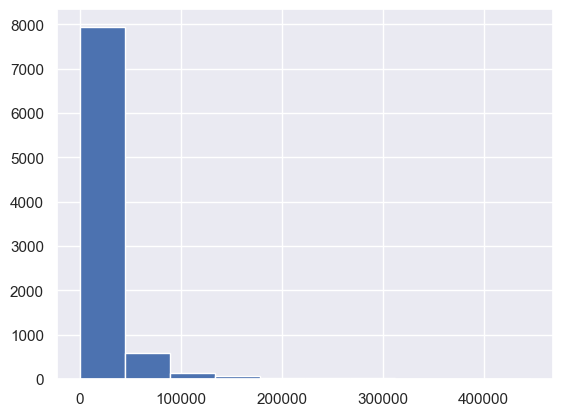

In [88]:
df_pipe6['Four_num'].hist()

удаляем из df_pipe6 6 признаков с нулевыми весами и старое поле `app_opens_crashes_days_since` (произведение полей: df_pipe['app_opens_per_week']*df_pipe['app_crashes_last_month']*df_pipe['days_since_last_promo']).

Разбиваем на train_val и test

In [89]:
df_pipe6.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8786 entries, 9841 to 5962
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     8786 non-null   float32
 1   order_frequency_month     8786 non-null   float32
 2   avg_order_value           8786 non-null   float32
 3   median_order_value        8786 non-null   float32
 4   total_spent_last_month    8786 non-null   float64
 5   discount_usage_rate       8786 non-null   float32
 6   last_coffee_type          8786 non-null   object 
 7   preferred_roast           8786 non-null   object 
 8   milk_preference           8786 non-null   object 
 9   seasonal_menu_tried       8786 non-null   object 
 10  coffee_bean_origin        8786 non-null   object 
 11  last_drink_size           8786 non-null   object 
 12  subscription_status       8786 non-null   object 
 13  app_opens_per_week        8786 non-null   float32
 14  notificati

In [90]:
df_pipe6=df_pipe6.drop(columns=['coffee_preference_change', 
                                        'days_since_last_promo', 
                                        'review_rating_last_10',
                                        'discount_usage_rate', 
                                        'avg_order_value', 
                                        'seasonal_menu_tried'
                                        ], axis=1)
print(df_pipe6.info())

<class 'pandas.core.frame.DataFrame'>
Index: 8786 entries, 9841 to 5962
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   days_since_last_order   8786 non-null   float32
 1   order_frequency_month   8786 non-null   float32
 2   median_order_value      8786 non-null   float32
 3   total_spent_last_month  8786 non-null   float64
 4   last_coffee_type        8786 non-null   object 
 5   preferred_roast         8786 non-null   object 
 6   milk_preference         8786 non-null   object 
 7   coffee_bean_origin      8786 non-null   object 
 8   last_drink_size         8786 non-null   object 
 9   subscription_status     8786 non-null   object 
 10  app_opens_per_week      8786 non-null   float32
 11  notifications_enabled   8786 non-null   object 
 12  app_crashes_last_month  8786 non-null   float32
 13  seasons                 8786 non-null   object 
 14  phone_type              8786 non-null   ob

In [91]:

X6 = df_pipe6.drop(columns='churn')
y6 = df_pipe6['churn']

 # разделяем на train и test
X6_train_val, X6_test, y6_train_val, y6_test = train_test_split(X6, y6, test_size=0.2, stratify=y6,
                                                           random_state=RANDOM_STATE)

In [92]:
class Log2Transformer(BaseEstimator, TransformerMixin):
        def __init__(self):
            super().__init__()  # Явное обращение к родительскому инициализатору
            
        def fit(self, X, y=None):
            return self  # Обязательный возврат self. Здесь Трансформер не нуждается в обучении для задачи логарифмир

        def transform(self, X):
        #"""Применяем логарифмирование к числовым полям — основной этап обработки."""
            X = pd.DataFrame(X)  # Убедимся, что работаем с DataFrame
            X_copy = X.copy()  # Создаём копию, чтобы не изменять исходные данные

            for column in X_copy.columns:
                if np.issubdtype(X[column].dtype, np.number):
                    X_copy[column] = X_copy[column].where(X_copy[column] > 0, 1e-10) # или X[column].mask(X[column] <= 0, 1e-10) 
                    X_copy[column] = np.log1p(X_copy[column])   
            return X_copy

        def get_feature_names_out(self, input_features=None):
            if input_features is None:
                input_features = [f'feature_{i}' for i in range(X.shape[1])]
            return input_features  # возвращаем исходные имена

num_column = [ 'app_crashes_last_month', 
               'notifications_enabled'
              ]
log_column = ['days_since_last_order', 'order_frequency_month', 
              'median_order_value', 'total_spent_last_month', 
              'app_opens_per_week', 'Four_num']

cat1_column = ['last_coffee_type', 'preferred_roast', 'milk_preference',  
               'coffee_bean_origin', 'last_drink_size', 'subscription_status', 
               'seasons',  'phone_type']
 
geo_location_column = ['geo_location']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) 

# словарь cv_results для сохранения результатов по трём метрикам: accuracy, F1-мера и ROC-AUC.
# посмотрим, может ещё какие метрики добавить надо будет!
    
cv_results={
        'accuracy' : [],
        'f1' : [],
        'pr_auc' : [],
}

X6_train_val = X6_train_val.reset_index(drop=True) 
y6_train_val = y6_train_val.reset_index(drop=True) 

num_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
log_pipeline=Pipeline(steps=[
        ('log', Log2Transformer()),
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
cat_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])
geo_location_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('Target_Encoder', TargetEncoder())
    ])

preprocessor=ColumnTransformer(
        transformers=[
            ('num_pipeline', num_pipeline, num_column),
            ('log_pipeline', log_pipeline, log_column),
            ('cat_pipeline', cat_pipeline, cat1_column),
            ('geo_location_pipeline', geo_location_pipeline, geo_location_column)
    ])
full_pipeline=Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('model',LogisticRegression())
])
                       
res2 = cross_validate(
    estimator=full_pipeline,           # модель или pipeline
    X=X6_train_val,                          # признаки
    y=y6_train_val,                          # целевая переменная
    scoring=['accuracy', 'f1', 'average_precision'],   # список метрик
    cv=cv,                        # стратегия разбиения
    return_train_score = True,    # расчёт качества на трейне
    return_estimator = True,      # сохранение обученных экземпляров модели
    n_jobs=-1                     # использовать все ядра
) 

cv_results_mean2 = {
     'accuracy': np.mean(res2["train_accuracy"]).round(3),  # среднее значение
     'f1': np.mean(res2["train_f1"]).round(3),        # среднее значение
    'pr_auc': np.mean(res2["train_average_precision"]).round(3)
}

print(cv_results_mean2)

{'accuracy': np.float64(0.963), 'f1': np.float64(0.617), 'pr_auc': np.float64(0.708)}


Модель 6 стала хуже модели 5. **Создадим модель7**: числовое поле `Four_num` удалим и снова построим модель. В этой модели нет 6 признаков: 'coffee_preference_change', 
                                        'days_since_last_promo', 
                                        'review_rating_last_10',
                                        'discount_usage_rate', 
                                        'avg_order_value', 
                                        'seasonal_menu_tried'

In [93]:
df_pipe7=df_pipe6.copy()
df_pipe7=df_pipe7.drop(columns='Four_num')

In [94]:
X7 = df_pipe7.drop(columns='churn')
y7 = df_pipe7['churn']

 # разделяем на train и test
X7_train_val, X7_test, y7_train_val, y7_test = train_test_split(X7, y7, test_size=0.2, stratify=y7,
                                                           random_state=RANDOM_STATE)

In [95]:
class Log2Transformer(BaseEstimator, TransformerMixin):
        def __init__(self):
            super().__init__()  # Явное обращение к родительскому инициализатору
            
        def fit(self, X, y=None):
            return self  # Обязательный возврат self. Здесь Трансформер не нуждается в обучении для задачи логарифмир

        def transform(self, X):
        #"""Применяем логарифмирование к числовым полям — основной этап обработки."""
            X = pd.DataFrame(X)  # Убедимся, что работаем с DataFrame
            X_copy = X.copy()  # Создаём копию, чтобы не изменять исходные данные

            for column in X_copy.columns:
                if np.issubdtype(X[column].dtype, np.number):
                    X_copy[column] = X_copy[column].where(X_copy[column] > 0, 1e-10) # или X[column].mask(X[column] <= 0, 1e-10) 
                    X_copy[column] = np.log1p(X_copy[column])   
            return X_copy

        def get_feature_names_out(self, input_features=None):
            if input_features is None:
                input_features = [f'feature_{i}' for i in range(X.shape[1])]
            return input_features  # возвращаем исходные имена

num_column = [ 'app_crashes_last_month', 
               'notifications_enabled'
              ]
log_column = ['days_since_last_order', 'order_frequency_month', 
              'median_order_value', 'total_spent_last_month', 
              'app_opens_per_week']

cat1_column = ['last_coffee_type', 'preferred_roast', 'milk_preference',  
               'coffee_bean_origin', 'last_drink_size', 'subscription_status', 
               'seasons',  'phone_type']

geo_location_column = ['geo_location']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) 

# словарь cv_results для сохранения результатов по трём метрикам: accuracy, F1-мера и ROC-AUC.
# посмотрим, может ещё какие метрики добавить надо будет!
    
cv_results={
        'accuracy' : [],
        'f1' : [],
        'pr_auc' : [],
}

X7_train_val = X7_train_val.reset_index(drop=True) 
y7_train_val = y7_train_val.reset_index(drop=True) 

num_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
log_pipeline=Pipeline(steps=[
        ('log', Log2Transformer()),
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
cat_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])
geo_location_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('Target_Encoder', TargetEncoder())
    ])

preprocessor=ColumnTransformer(
        transformers=[
            ('num_pipeline', num_pipeline, num_column),
            ('log_pipeline', log_pipeline, log_column),
            ('cat_pipeline', cat_pipeline, cat1_column),
            ('geo_location_pipeline', geo_location_pipeline, geo_location_column)
    ])
full_pipeline=Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('model',LogisticRegression())
])
                       
res3 = cross_validate(
    estimator=full_pipeline,           # модель или pipeline
    X=X7_train_val,                          # признаки
    y=y7_train_val,                          # целевая переменная
    scoring=['accuracy', 'f1', 'average_precision'],   # список метрик
    cv=cv,                        # стратегия разбиения
    return_train_score = True,    # расчёт качества на трейне
    return_estimator = True,      # сохранение обученных экземпляров модели
    n_jobs=-1                     # использовать все ядра
) 

cv_results_mean3 = {
     'accuracy': np.mean(res3["train_accuracy"]).round(3),  # среднее значение
     'f1': np.mean(res3["train_f1"]).round(3),        # среднее значение
    'pr_auc': np.mean(res3["train_average_precision"]).round(3)
}

print(cv_results_mean3)

{'accuracy': np.float64(0.962), 'f1': np.float64(0.61), 'pr_auc': np.float64(0.708)}


**Создадим таблицу с результатами**

In [96]:
all_results = {
    'model1': {
        'strategy': 'KFold',
        'metrics': {
            'Accuracy': round(np.mean(cv_results1['accuracy']), 4),
            'F1-score': round(np.mean(cv_results1['f1']), 4),
            'PR-AUC' : round(np.mean(cv_results1['pr_auc']), 4)}
        },
    'model_base': {
        'strategy': 'KFold',
        'metrics': {
            'Accuracy': round(np.mean(cv_results2['accuracy']), 4),
            'F1-score': round(np.mean(cv_results2['f1']), 4),
            'PR-AUC' : round(np.mean(cv_results2['pr_auc']), 4)}
        },
    'model3': {
        'strategy': 'KFold',
        'metrics': {
            'Accuracy': round(np.mean(cv_results3['accuracy']), 4),
            'F1-score': round(np.mean(cv_results3['f1']), 4),
            'PR-AUC' : round(np.mean(cv_results3['pr_auc']), 4)}
        },
    'model4': {
        'strategy': 'KFold',
        'metrics': {
            'Accuracy': round(np.mean(cv_results4['accuracy']), 4),
            'F1-score': round(np.mean(cv_results4['f1']), 4),
            'PR-AUC' : round(np.mean(cv_results4['pr_auc']), 4)}
        },
    'model4_2': {
        'strategy': 'KFold',
        'metrics': {
            'Accuracy': round(np.mean(cv_results5['accuracy']), 4),
            'F1-score': round(np.mean(cv_results5['f1']), 4),
            'PR-AUC' : round(np.mean(cv_results5['pr_auc']), 4)}
        },
    'model5': {
        'strategy': 'StratifiedKFold',
        'metrics': {
            'Accuracy': round(np.mean(res1['train_accuracy']), 4),
            'F1-score': round(np.mean(res1['train_f1']), 4),
            'PR-AUC' : round(np.mean(res1['train_average_precision']), 4)}
        },
    'model6': {
        'strategy': 'StratifiedKFold',
        'metrics': {
            'Accuracy': round(np.mean(res2['train_accuracy']), 4),
            'F1-score': round(np.mean(res2['train_f1']), 4),
            'PR-AUC' : round(np.mean(res2['train_average_precision']), 4)}
        },
    'model7': {
        'strategy': 'StratifiedKFold',
        'metrics': {
            'Accuracy': round(np.mean(res3['train_accuracy']), 4),
            'F1-score': round(np.mean(res3['train_f1']), 4),
            'PR-AUC' : round(np.mean(res3['train_average_precision']), 4)}
        },
    'model8': {
        'strategy': 'StratifiedKFold',
        'metrics': {
            'Accuracy': round(np.mean(res4['train_accuracy']), 4),
            'F1-score': round(np.mean(res4['train_f1']), 4),
            'PR-AUC' : round(np.mean(res4['train_average_precision']), 4)}
        },
}

print("Сводка по моделям:")
print("=" * 50)

for model_name, model_data in all_results.items():
    # Получаем стратегию и метрики для текущей модели
    strategy = model_data['strategy']
    metrics = model_data['metrics']
    
    # Выводим заголовок для модели
    print(f"\nМодель: {model_name}")
    print(f"Стратегия валидации: {strategy}")
    print("-" * 50)
    
    # Выводим метрики в виде таблицы
    print(f"| {'Метрика':<15} | {'Значение':<10} |")
    print("-" * 30)
    for metric_name, value in metrics.items():
        # :.4f форматирует число до 4 знаков после запятой
        print(f"| {metric_name:<15} | {value:<10.4f} |")
    
    print("=" * 50)


Сводка по моделям:

Модель: model1
Стратегия валидации: KFold
--------------------------------------------------
| Метрика         | Значение   |
------------------------------
| Accuracy        | 0.9579     |
| F1-score        | 0.5492     |
| PR-AUC          | 0.6417     |

Модель: model_base
Стратегия валидации: KFold
--------------------------------------------------
| Метрика         | Значение   |
------------------------------
| Accuracy        | 0.9575     |
| F1-score        | 0.5561     |
| PR-AUC          | 0.6565     |

Модель: model3
Стратегия валидации: KFold
--------------------------------------------------
| Метрика         | Значение   |
------------------------------
| Accuracy        | 0.9570     |
| F1-score        | 0.5327     |
| PR-AUC          | 0.6290     |

Модель: model4
Стратегия валидации: KFold
--------------------------------------------------
| Метрика         | Значение   |
------------------------------
| Accuracy        | 0.9603     |
| F1-score     

Лучшая модель model5

## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


**модель 5) к модели 4 применю StratifiedKFold** с лучшими результатами 0,71

выполню кросс-валидацию без циклов, с помощью функции cross_validate
Воспользуюсь подготовленными, разделенными  датафреймами модели 4
X4_train_val, X4_test, y4_train_val, y4_test

In [97]:
X4_train_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7028 entries, 0 to 7027
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     7028 non-null   float32
 1   order_frequency_month     7028 non-null   float32
 2   avg_order_value           7028 non-null   float32
 3   median_order_value        7028 non-null   float32
 4   total_spent_last_month    7028 non-null   float64
 5   discount_usage_rate       7028 non-null   float32
 6   last_coffee_type          7028 non-null   object 
 7   preferred_roast           7028 non-null   object 
 8   milk_preference           7028 non-null   object 
 9   seasonal_menu_tried       7028 non-null   object 
 10  coffee_bean_origin        7028 non-null   object 
 11  last_drink_size           7028 non-null   object 
 12  subscription_status       7028 non-null   object 
 13  app_opens_per_week        7028 non-null   float32
 14  notifica

На **этапе 9**, сохранения модели5, столкнулась с тем, что класс **Log2Transformer** напрямую **joblib** обработать не может. Надо либо класс отдельно сохранять и импортировать, как модуль, в jupyter. Это не приемлемо в данном случаае, поскольку файл надо отправлять на проверку. Либо использовать dill.dump. Решила, что это тоже не удобно и использовать материалы курса (хотя про FunctionTransformer очень "вскользь" упоминается). 

Переписала класс **Log2Transformer** на функцию ***log_change** с использованием **FunctionTransformer**.

In [98]:
# from sklearn.preprocessing import FunctionTransformer

def log_change(X):
    """
    Проверяет датафрейм и логарифмирует числовые колонки
    """
    X = pd.DataFrame(X)  # Убедимся, что работаем с DataFrame
    X_copy = X.copy()  # Создаём копию, чтобы не изменять исходные данные
    
    for column in X_copy.columns:
        if np.issubdtype(X[column].dtype, np.number):
            X_copy[column] = X_copy[column].where(X_copy[column] > 0, 1e-10) # или X[column].mask(X[column] <= 0, 1e-10) 
            X_copy[column] = np.log1p(X_copy[column])   
    return X_copy    


num_column = [ 'discount_usage_rate', 'review_rating_last_10', 'app_crashes_last_month', 
               'seasonal_menu_tried','notifications_enabled', 
              'coffee_preference_change']
log_column = ['days_since_last_order', 'order_frequency_month', 'avg_order_value', 
              'median_order_value', 'total_spent_last_month', 
              'app_opens_per_week', 'days_since_last_promo']

cat1_column = ['last_coffee_type', 'preferred_roast', 'milk_preference',  
               'coffee_bean_origin', 'last_drink_size', 'subscription_status', 
               'seasons',  'phone_type']
geo_location_column = ['geo_location']


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) 

# словарь cv_results для сохранения результатов по трём метрикам: accuracy, F1-мера и ROC-AUC.
# посмотрим, может ещё какие метрики добавить надо будет!
    
cv_results={
        'accuracy' : [],
        'f1' : [],
        'pr_auc' : [],
}

X4_train_val = X4_train_val.reset_index(drop=True) 
y4_train_val = y4_train_val.reset_index(drop=True) 

num_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
log_pipeline=Pipeline(steps=[
        ('log', FunctionTransformer(log_change, validate=False)),
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
cat_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])
geo_location_pipeline=Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('Target_Encoder', TargetEncoder())
    ])

preprocessor=ColumnTransformer(
        transformers=[
            ('num_pipeline', num_pipeline, num_column),
            ('log_pipeline', log_pipeline, log_column),
            ('cat_pipeline', cat_pipeline, cat1_column),
            ('geo_location_pipeline', geo_location_pipeline, geo_location_column)
    ])
full_pipeline5=Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('model',LogisticRegression())
])
                       
res1 = cross_validate(
    estimator=full_pipeline5,           # модель или pipeline
    X=X4_train_val,                          # признаки
    y=y4_train_val,                          # целевая переменная
    scoring=['accuracy', 'f1', 'average_precision'],   # список метрик
    cv=cv,                        # стратегия разбиения
    return_train_score = True,    # расчёт качества на трейне
    return_estimator = True,      # сохранение обученных экземпляров модели
    n_jobs=-1                     # использовать все ядра
) 

cv_results_mean1 = {
     'accuracy': np.mean(res1["train_accuracy"]).round(3),  # среднее значение
     'f1': np.mean(res1["train_f1"]).round(3),        # среднее значение
    'pr_auc': np.mean(res1["train_average_precision"]).round(3)
}

print(cv_results_mean1)


{'accuracy': np.float64(0.962), 'f1': np.float64(0.617), 'pr_auc': np.float64(0.71)}


Обучим модель5 на всех данных

In [99]:
print("Обучение финальной модели5 на всей тренировочной выборке...")
final_trained_pipeline = full_pipeline5.fit(X4_train_val, y4_train_val)
print("Модель5 обучена.")

Обучение финальной модели5 на всей тренировочной выборке...
Модель5 обучена.


In [100]:
print("\nДелаем предсказания на тестовой выборке...")

# 1. Предсказываем классы (0 или 1)
y_pred = final_trained_pipeline.predict(X4_test)


Делаем предсказания на тестовой выборке...


In [101]:
# 2. Предсказываем вероятности (нужно для ROC-AUC и PR-AUC)
y_pred_proba = final_trained_pipeline.predict_proba(X4_test)[:, 1] # Берем вероятность класса 1

print("Предсказания сделаны.")

Предсказания сделаны.


In [102]:
# Оценим, как модель5 работает на новых, тестовых  данных y4_test.

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

print("\n--- ОЦЕНКА КАЧЕСТВА НА ТЕСТОВОЙ ВЫБОРКЕ ---")

test_accuracy = accuracy_score(y4_test, y_pred)
test_f1 = f1_score(y4_test, y_pred)
test_pr_auc = average_precision_score(y4_test, y_pred_proba)

print(f"Точность (Accuracy) на тесте: {test_accuracy:.4f}")
print(f"F1-мера на тесте: {test_f1:.4f}")
print(f"PR-AUC на тесте: {test_pr_auc:.4f}")



--- ОЦЕНКА КАЧЕСТВА НА ТЕСТОВОЙ ВЫБОРКЕ ---
Точность (Accuracy) на тесте: 0.9642
F1-мера на тесте: 0.6400
PR-AUC на тесте: 0.7172


На тестовой y4_test выборке PR-AUC=0.717 похожа на результаты по обучающей выборке X4_train_val, где PR-AUC=0.71. Тестовая метрика немного лучше, что означает отсутствие переобучения, а модель научилавь распознавать закономерности.

## Этап 8. Отчёт о проделанной работе

Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.

- разработан пайплайн для боработки данных
- создано и проверено 8 моделей по анализу качества которых была отобрана модель5 с наилучшими характеристиками, а также DummyClassifier модель.
- анализировала три метрики:
        -  **Accuracy**: определяет процент всех правильных предсказаний. Работает на сбалансированных данных. Поэтому для нашей задачи, классификации оттока клиента, - бесполезна. Оставила её для сравнения с **DummyClassifier**, точность которой **0.89**. Значит точность наших моделей должна быть выше. В основном **Accuracy** в исследовании колеблется от **0.9570 (модель3)** до **0.9625 (модель6)**. Значит наши модели лучше **DummyClassifier**. **Accuracy** нельзя сравнивать с **F1** и **PR-AUC** поскольку метрики не сопоставимы.
        - **F1**: соблюдает баланс между точностью **(Precision)** и полнотой **(Recall)**, гармоническое среднее. Хороша, когда данные разбиты примерно одинаково и оценивается положительный класс. В нашем исследовании, её значения находятся около середины, от **0.5327 (модель3)** до **0.6172 (модель6)**. В нашем случае, эта метрика также не подходит, поскольку в целевой веременной обнаружен сильный дисбаланс между классами **94%** к **6%**. Используя эту метрику мы много пропустим верных предсказаний и будет, также, много ошибочных предсказаний.
        - **PR-AUC**: показывает как меняется баланс между **Precision** и **Recall***, хорошо подходит для изучения несбалансированных данных. Это наш случай! В моделях значения по этой метрике варьируются от **0.6290 (модель3)** до  **0.7021   (модель4_2)** при стратегии **KFold**. В случае применения стратегии **StratifiedKFold** эта метрика ещё возрасла до **0,71** в **модели5**. 
- кроме метрик, изучила применение методов кросс-валидации **KFold** и **StratifiedKFold**. Их суть заключается в том, КАК на группы разбиты данные выборки. Первый метод не учитывает баланс классов, а второй - учитывает. Поэтому, для решения нашей задачи, **StratifiedKFold** предпочтительнее, поскольку сохраняет исходное соотношение классов в группах (фолдах). Применение этого метода для формирования групп существенно повысило качество моделей5-8.
- также, на качество модели, оказал **способ предобработки данных**: применение к числовым признакам **матемтических преобразований**. Они сохраняют характер распределения ряда, но позволяют его масштабировать, тем самым, позволяя модели лучше обнаруживать закономерности. Мы использовали:
        - логарифмирование всех числовых признаков;
        - возведение в квадрат и извлечение квадратного корня к двум группам числовых признаков в зависимости от характера распределения;
        - **логарифмирование части признаков**, с "длиннохвостыми" распределениями. Остальные числовые столбцы не преобразовывались. Эта стратегия оказалась наиболее удачной, поэтому дальнейшее изучение метрик и методов проводилось на, преобразованных таким образом, данных.
- ещё один способ улучшить качество модели - **создание новых числовых признаков**, на  основе имеющихся. Такая техника позволяет увеличить вес малосущественных признаков. В нашем исследовании, этот способ успешных результатов **не показал**. В **моделях 3** и **6** создавались новые признаки.  И нами был сделан вывод, что в данной задачи классификации, использование новых вычисляемых признаков - **бесполезно, не эффективно**.
- Кроме того, анализ коэффициентов модлелей показал, что наибольшее влияние **на отток клиента** оказывается: **работоспособностью приложения (`app_crashes_last_month`)** и **геолокация (зависимость от региона), поле `geo_location`** и сколько раз приложение зависало за последний месяц.   

Модель5 определена как наиболее успешная, она в 71% слчаев позволяет спрогнозировать отток клиентов.

Возможная стратегия для бизнеса:

- улучшить технические характеристики работы приложения, поскольку это главный фактор оттока клиентов (зависающее приложение `app_crashes_last_month`)
- провести оснащение регионов. Потому что сейчас, чем больше регионов и не стабильно работает приложение, тем больше отток клиентов.

Также, разработать массовые акции по удержанию клиентов, с опорой на предпочтения клиентов, в комбинации с точечной работой с клиентами 



## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.

Для **сохранения модели5** используем **joblib**, предварительно инсталировали и импортировали joblib

In [103]:
joblib.dump(final_trained_pipeline, 'model5.joblib')

['model5.joblib']

Проверка: загрузим модель, загрузим данные по новому клиенту и сделаем предсказание

In [104]:
loaded_pipeline = joblib.load('model5.joblib')

# данные нового клиента
nwe_cust = pd.DataFrame({
    'days_since_last_order' : [5],
    'order_frequency_month' : [4.56],
    'avg_order_value' : [750.25],
    'median_order_value' : [850],
    'total_spent_last_month' : [1789.2],
    'discount_usage_rate' : [0.2],
    'last_coffee_type' : 'arabica',
    'preferred_roast' : 'medium',
    'milk_preference' : 'almond',
    'seasonal_menu_tried' : '1',
    'coffee_bean_origin' : 'brazil',
    'last_drink_size' : 'small',
    'subscription_status' : 'pro',
    'app_opens_per_week' : [5],
    'notifications_enabled' : '0',
    'review_rating_last_10' : [3.5],
    'app_crashes_last_month' : [1],
    'seasons' : 'spring',
    'days_since_last_promo' : [23],
    'phone_type' : 'android',
    'coffee_preference_change' : '0',
    'geo_location' : 'geo_4'
})

# Сделаем предсказание и сохраним в переменную prediction
prediction = loaded_pipeline.predict(nwe_cust[:5]) 
print(f"Предсказание для нового клиента: {prediction}")

Предсказание для нового клиента: [0]


Модель5 сохранена корректно, работает и предсказывает